In [1]:
import torch
import numpy as np
from training import train
from data_utils import make_dataset, load_dataset, fit_dset_to_m, make_grid_dataset
from controls import LQR
from tasks import stabilize_cartpole
from plotting import plot_trajectories, plot_experiment_new
from models import save_model, load_model
from experiments import save_experiment, load_experiment
import params
from IPython.display import HTML
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

######################
### DISPLAY CONFIG ###
######################
for name, values in vars(params).items():
    print(name, values)

torch.set_default_device("cuda")
#torch.set_default_device("cpu")

%load_ext autoreload
%autoreload 2

/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


__name__ params
__doc__ None
__package__ 
__loader__ <_frozen_importlib_external.SourceFileLoader object at 0x7f6d6bddfc50>
__spec__ ModuleSpec(name='params', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f6d6bddfc50>, origin='/home1/lutkus/latent_space/cartpole_lyapunov/params.py')
__file__ /home1/lutkus/latent_space/cartpole_lyapunov/params.py
__cached__ /home1/lutkus/latent_space/cartpole_lyapunov/__pycache__/params.cpython-313.pyc
__builtins__ {'__name__': 'builtins', '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.", '__package__': '', '__loader__': <class '_frozen_impor

In [2]:
################################
### Load or Generate Dataset ###
################################

#data = make_dataset(save=True, fname=params.dataset, render_mode=None, expert_controller=False)
#data = make_grid_dataset(params.grid_x_ranges, params.grid_u_ranges, params.grid_n_per_axis) # UNCOMMENT THIS TO MAKE DATASET
data, normalization_constants = load_dataset(fname=params.dataset, normalize=False)
params.normalization_constants = normalization_constants
print(params.normalization_constants)
X, U, Xtest, Utest = data

None


/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


original state:
 [(0, 1, 3), (2,)]
n_combinations 4
n_params 2
{'ae': [('symbols=(0, 1, 2, 3)\nignored=()', []), ('symbols=(0, 1, 3)\nignored=(2,)', []), ('symbols=(1, 2, 3)\nignored=(0,)', []), ('symbols=(1, 3)\nignored=(0, 2)', [])], 'fdyn': [('symbols=(0, 1, 2, 3)\nignored=()', []), ('symbols=(0, 1, 3)\nignored=(2,)', []), ('symbols=(1, 2, 3)\nignored=(0,)', []), ('symbols=(1, 3)\nignored=(0, 2)', [])], 'ae_opt': [('symbols=(0, 1, 2, 3)\nignored=()', []), ('symbols=(0, 1, 3)\nignored=(2,)', []), ('symbols=(1, 2, 3)\nignored=(0,)', []), ('symbols=(1, 3)\nignored=(0, 2)', [])], 'fdyn_opt': [('symbols=(0, 1, 2, 3)\nignored=()', []), ('symbols=(0, 1, 3)\nignored=(2,)', []), ('symbols=(1, 2, 3)\nignored=(0,)', []), ('symbols=(1, 3)\nignored=(0, 2)', [])], 'ae_list': [('symbols=(0, 1, 2, 3)\nignored=()', []), ('symbols=(0, 1, 3)\nignored=(2,)', []), ('symbols=(1, 2, 3)\nignored=(0,)', []), ('symbols=(1, 3)\nignored=(0, 2)', [])], 'fdyn_list': [('symbols=(0, 1, 2, 3)\nignored=()', []), ('s

  2%|▏         | 1/50 [00:15<12:35, 15.41s/it]

ep 0: train 0.4884302020072937    test 2.416978120803833
rec 0.44199031591415405    mstep 0.04643969237804413    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:44, 14.68s/it]

21.079273
it: 2; avg reward: 286.42876877493774; completion rate: 0.66; gamma_max: 21.079273223876953
horizon is now 3


...

10.545108
it: 46; avg reward: 337.11621905025316; completion rate: 0.74; gamma_max: 10.5451078414917


 96%|█████████▌| 48/50 [33:18<01:32, 46.35s/it]

9.424747
it: 48; avg reward: 338.6910051511793; completion rate: 0.77; gamma_max: 9.424747467041016


100%|██████████| 50/50 [35:07<00:00, 42.15s/it]

ep 49: train 0.19965407252311707    test 0.19118884205818176
rec 0.09363536536693573    mstep 0.10601876676082611    jac 0.0


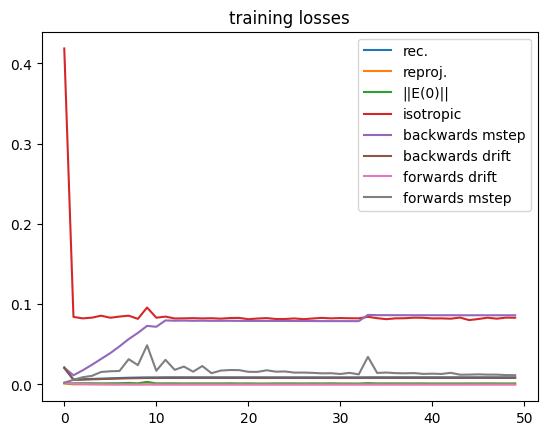

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:22, 15.16s/it]

ep 0: train 0.3498624265193939    test 2.116816759109497
rec 0.3261164128780365    mstep 0.02374570071697235    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:38, 14.55s/it]

18.035465
it: 2; avg reward: 374.54566620688087; completion rate: 0.72; gamma_max: 18.035465240478516
horizon is now 3


...

10.076305
it: 46; avg reward: 352.5640722190107; completion rate: 0.76; gamma_max: 10.076305389404297


 96%|█████████▌| 48/50 [33:10<01:32, 46.19s/it]

10.440335
it: 48; avg reward: 351.5599771940576; completion rate: 0.73; gamma_max: 10.440335273742676


100%|██████████| 50/50 [35:00<00:00, 42.01s/it]

ep 49: train 0.1983526200056076    test 0.18922989070415497
rec 0.09236978739500046    mstep 0.10598249733448029    jac 0.0


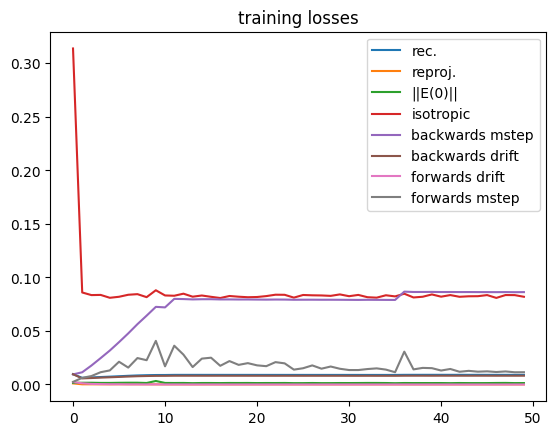

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:26, 15.24s/it]

ep 0: train 0.4742470979690552    test 2.1388516426086426
rec 0.4482135474681854    mstep 0.026034221053123474    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:41, 14.61s/it]

13.841004
it: 2; avg reward: 288.5027536862128; completion rate: 0.65; gamma_max: 13.841004371643066
horizon is now 3


...

12.72212
it: 46; avg reward: 450.18152398543214; completion rate: 0.86; gamma_max: 12.72212028503418


 96%|█████████▌| 48/50 [33:15<01:32, 46.10s/it]

12.108552
it: 48; avg reward: 494.00496387522514; completion rate: 0.89; gamma_max: 12.108551979064941


100%|██████████| 50/50 [35:04<00:00, 42.09s/it]

ep 49: train 0.19835323095321655    test 0.19816049933433533
rec 0.09389422833919525    mstep 0.10445904731750488    jac 0.0


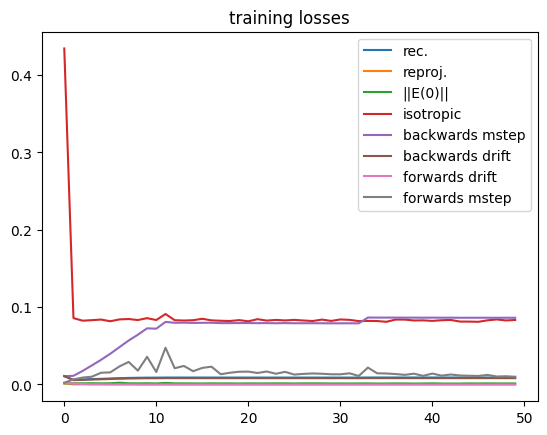

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:25, 15.22s/it]

ep 0: train 0.3861377239227295    test 2.2809364795684814
rec 0.3591608703136444    mstep 0.02697674185037613    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:36, 14.52s/it]

19.421972
it: 2; avg reward: 329.0113491069298; completion rate: 0.72; gamma_max: 19.421972274780273
horizon is now 3


...

12.13433
it: 46; avg reward: 413.1448248228552; completion rate: 0.85; gamma_max: 12.134329795837402


 96%|█████████▌| 48/50 [33:28<01:32, 46.16s/it]

11.749885
it: 48; avg reward: 440.87124816893316; completion rate: 0.82; gamma_max: 11.749884605407715


100%|██████████| 50/50 [35:16<00:00, 42.34s/it]

ep 49: train 0.1999005824327469    test 0.20851954817771912
rec 0.09324835985898972    mstep 0.10665225237607956    jac 0.0


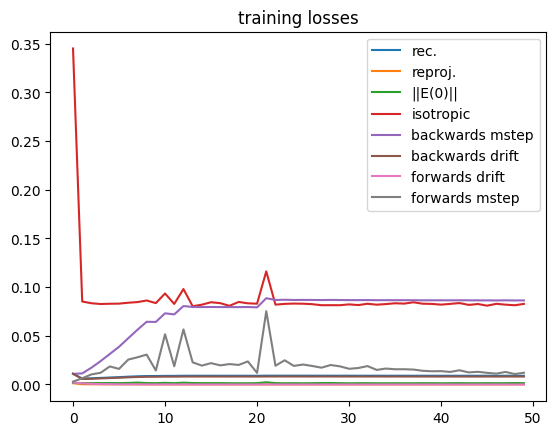

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:20, 15.10s/it]

ep 0: train 0.31260785460472107    test 2.1443052291870117
rec 0.2847083508968353    mstep 0.02789987437427044    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:39, 14.57s/it]

8.341649
it: 2; avg reward: 166.7043407272876; completion rate: 0.45; gamma_max: 8.341649055480957
horizon is now 3


...

10.846395
it: 46; avg reward: 400.6641716341854; completion rate: 0.75; gamma_max: 10.846394538879395


 96%|█████████▌| 48/50 [32:49<01:31, 45.77s/it]

9.783143
it: 48; avg reward: 277.36696062888166; completion rate: 0.75; gamma_max: 9.783143043518066


100%|██████████| 50/50 [34:37<00:00, 41.56s/it]

ep 49: train 0.19808559119701385    test 0.18851427733898163
rec 0.09248322248458862    mstep 0.10560232400894165    jac 0.0


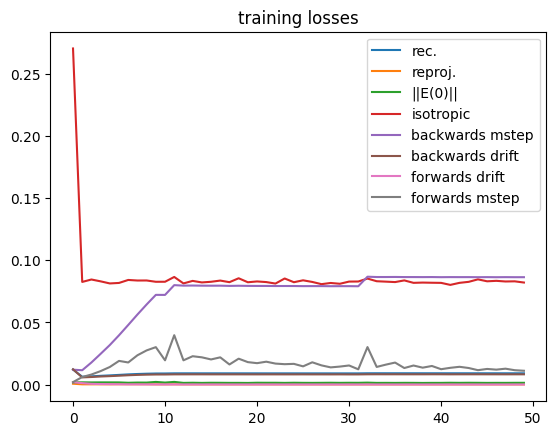

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:20, 15.12s/it]

ep 0: train 0.4809688925743103    test 2.981391191482544
rec 0.4414291977882385    mstep 0.03953998535871506    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:40, 14.60s/it]

10.979959
it: 2; avg reward: 214.35004490846538; completion rate: 0.41; gamma_max: 10.979958534240723
horizon is now 3


...

11.691812
it: 46; avg reward: 579.4869555830221; completion rate: 0.93; gamma_max: 11.691811561584473


 96%|█████████▌| 48/50 [33:14<01:32, 46.37s/it]

13.579307
it: 48; avg reward: 474.17864747031854; completion rate: 0.98; gamma_max: 13.579306602478027


100%|██████████| 50/50 [35:04<00:00, 42.09s/it]

ep 49: train 0.1990373283624649    test 0.18926852941513062
rec 0.0935322716832161    mstep 0.10550515353679657    jac 0.0


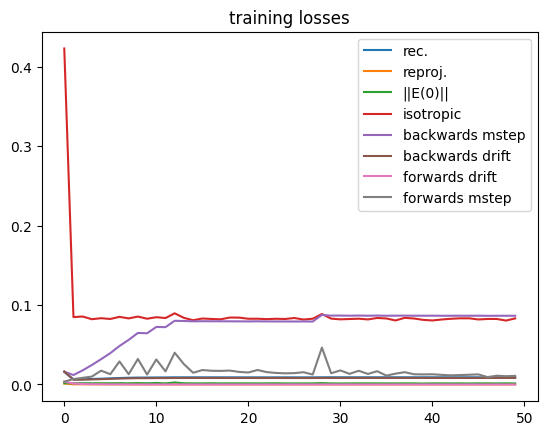

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:20, 15.12s/it]

ep 0: train 1.1079248189926147    test 3.5275719165802
rec 1.0586798191070557    mstep 0.049244608730077744    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:36, 14.51s/it]

14.263363
it: 2; avg reward: 495.30779380563786; completion rate: 0.98; gamma_max: 14.263362884521484
horizon is now 3


...

16.394188
it: 46; avg reward: 723.302667486235; completion rate: 1.0; gamma_max: 16.394187927246094


 96%|█████████▌| 48/50 [33:30<01:33, 46.58s/it]

17.268394
it: 48; avg reward: 706.1677659915189; completion rate: 1.0; gamma_max: 17.268394470214844


100%|██████████| 50/50 [35:20<00:00, 42.41s/it]

ep 49: train 0.19703452289104462    test 0.2082783728837967
rec 0.09220007061958313    mstep 0.10483434796333313    jac 0.0


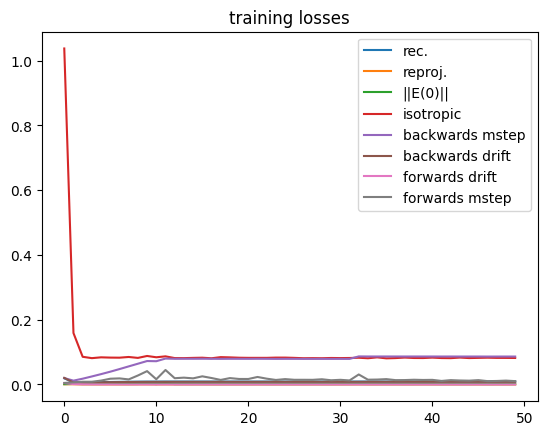

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:19, 15.10s/it]

ep 0: train 0.39474520087242126    test 2.1149399280548096
rec 0.3640345633029938    mstep 0.030710041522979736    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:36, 14.51s/it]

18.238073
it: 2; avg reward: 436.41970215776513; completion rate: 0.83; gamma_max: 18.238073348999023
horizon is now 3


...

12.386458
it: 46; avg reward: 474.13898554640315; completion rate: 0.83; gamma_max: 12.386458396911621


 96%|█████████▌| 48/50 [33:27<01:32, 46.29s/it]

11.718718
it: 48; avg reward: 393.2821177137036; completion rate: 0.82; gamma_max: 11.718717575073242


100%|██████████| 50/50 [35:16<00:00, 42.32s/it]

ep 49: train 0.19951467216014862    test 0.20216123759746552
rec 0.09490577131509781    mstep 0.10460866987705231    jac 0.0


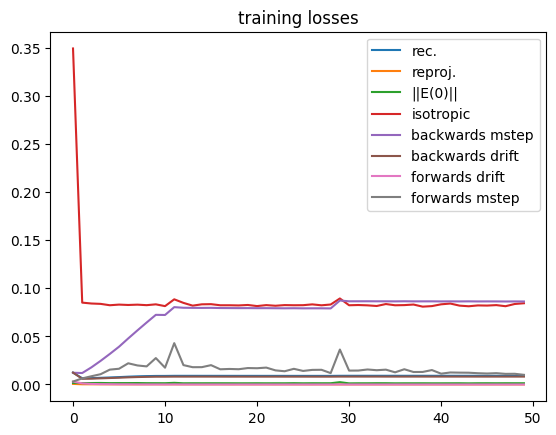

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:20, 15.10s/it]

ep 0: train 0.837586522102356    test 2.2660751342773438
rec 0.8013443946838379    mstep 0.03624200448393822    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:36, 14.50s/it]

19.932444
it: 2; avg reward: 348.98721199829413; completion rate: 0.83; gamma_max: 19.932443618774414
horizon is now 3


...

13.276939
it: 46; avg reward: 436.28903688256867; completion rate: 0.87; gamma_max: 13.276939392089844


 96%|█████████▌| 48/50 [33:35<01:33, 46.53s/it]

14.001755
it: 48; avg reward: 494.4792978912441; completion rate: 0.93; gamma_max: 14.001754760742188


100%|██████████| 50/50 [35:25<00:00, 42.51s/it]

ep 49: train 0.19907346367835999    test 0.21091927587985992
rec 0.09410035610198975    mstep 0.10497301071882248    jac 0.0


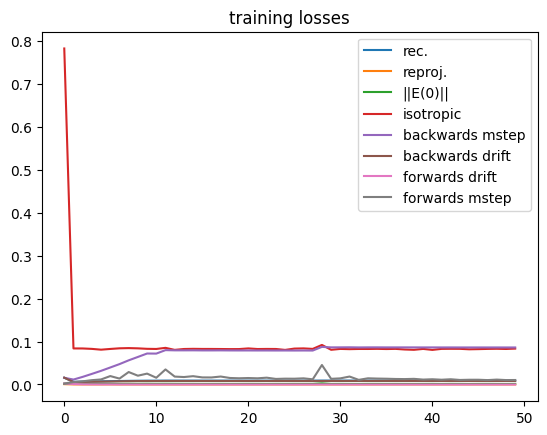

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function uniform_ at 0x7f6d6cecefc0>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6d6cecf600>
g bias init is <function zeros_ at 0x7f6d6cecf380>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7f6

  2%|▏         | 1/50 [00:15<12:19, 15.10s/it]

ep 0: train 0.32197076082229614    test 2.1630859375
rec 0.2972800135612488    mstep 0.024690425023436546    jac 0.0
horizon is now 2


  4%|▍         | 2/50 [00:29<11:36, 14.51s/it]

13.612561
it: 2; avg reward: 340.967080856485; completion rate: 0.5; gamma_max: 13.612561225891113
horizon is now 3


...

11.657438
it: 46; avg reward: 385.6095626829877; completion rate: 0.78; gamma_max: 11.657438278198242


 96%|█████████▌| 48/50 [32:09<01:28, 44.18s/it]

10.233904
it: 48; avg reward: 373.375336362494; completion rate: 0.78; gamma_max: 10.233903884887695


100%|██████████| 50/50 [33:52<00:00, 40.66s/it]

ep 49: train 0.1978578269481659    test 0.19765494763851166
rec 0.0935063287615776    mstep 0.10435134917497635    jac 0.0


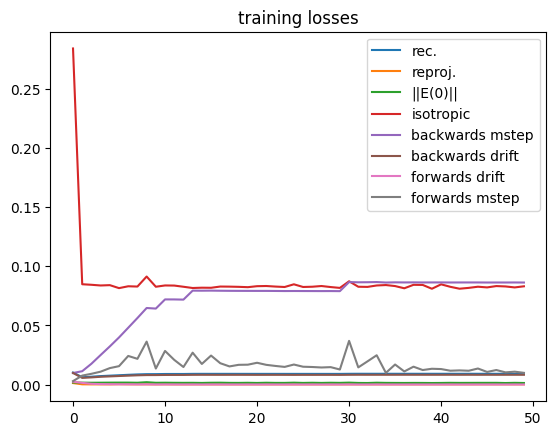

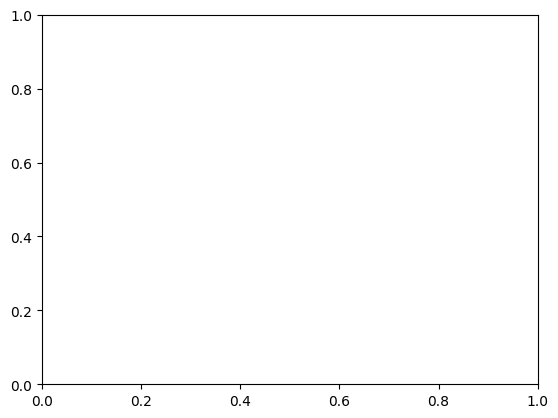

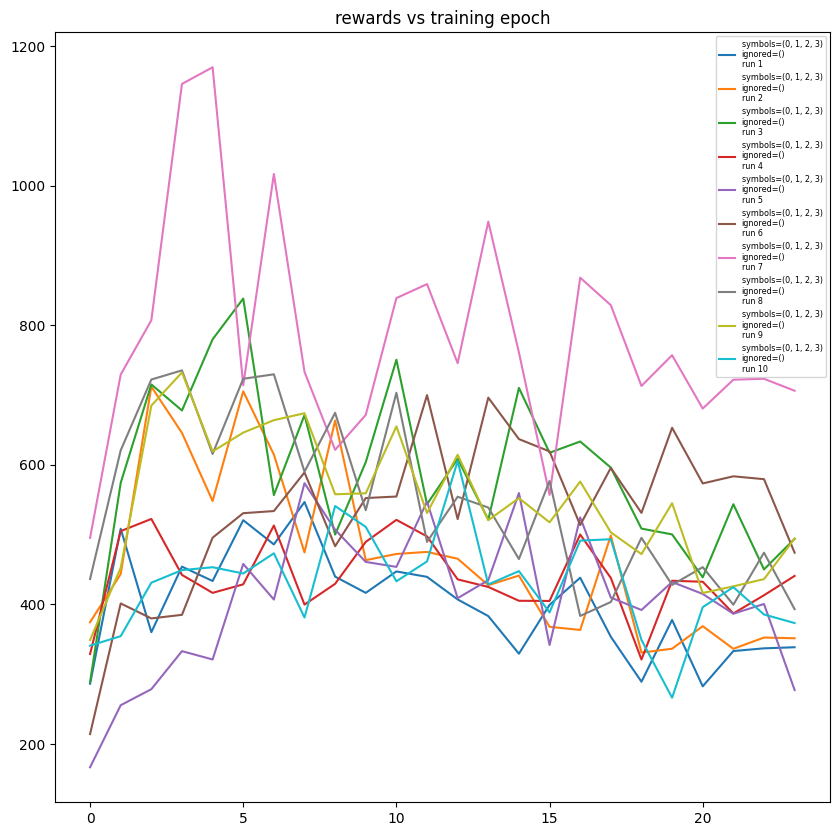

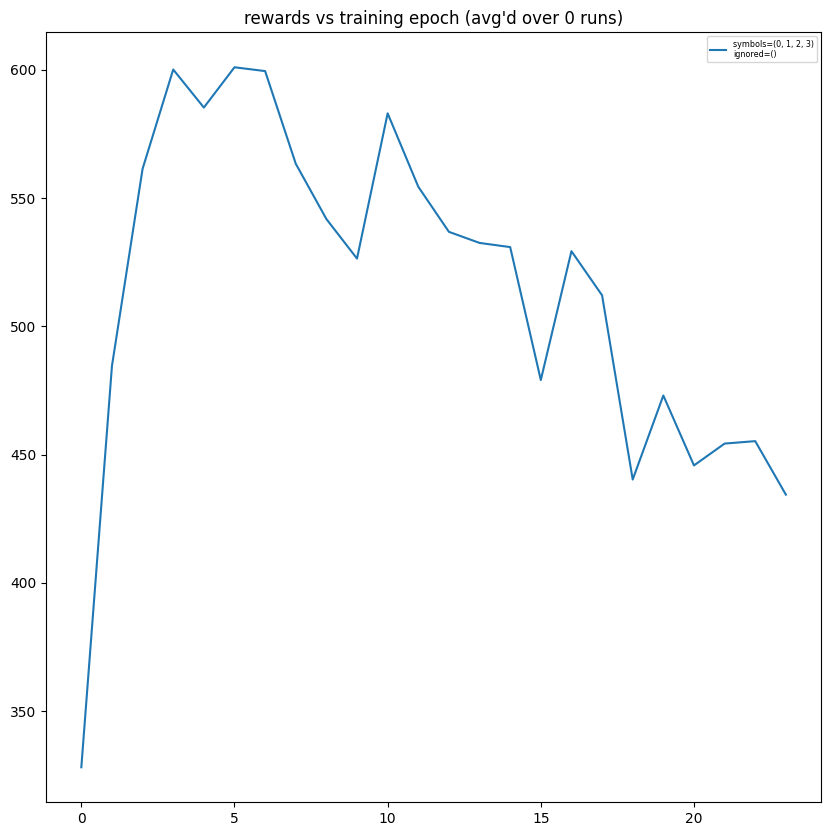

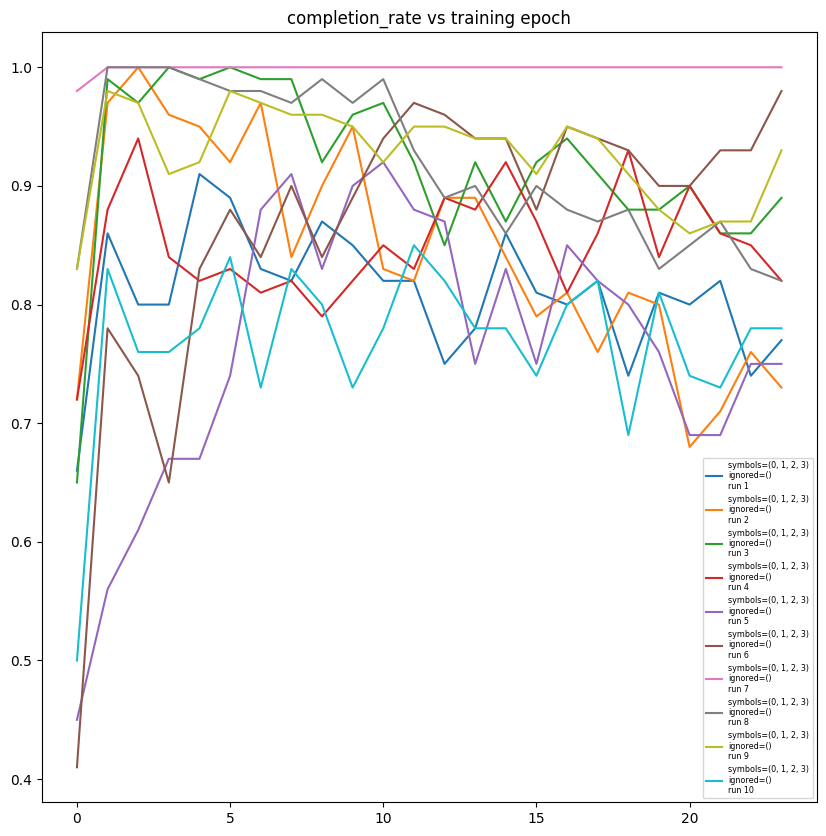

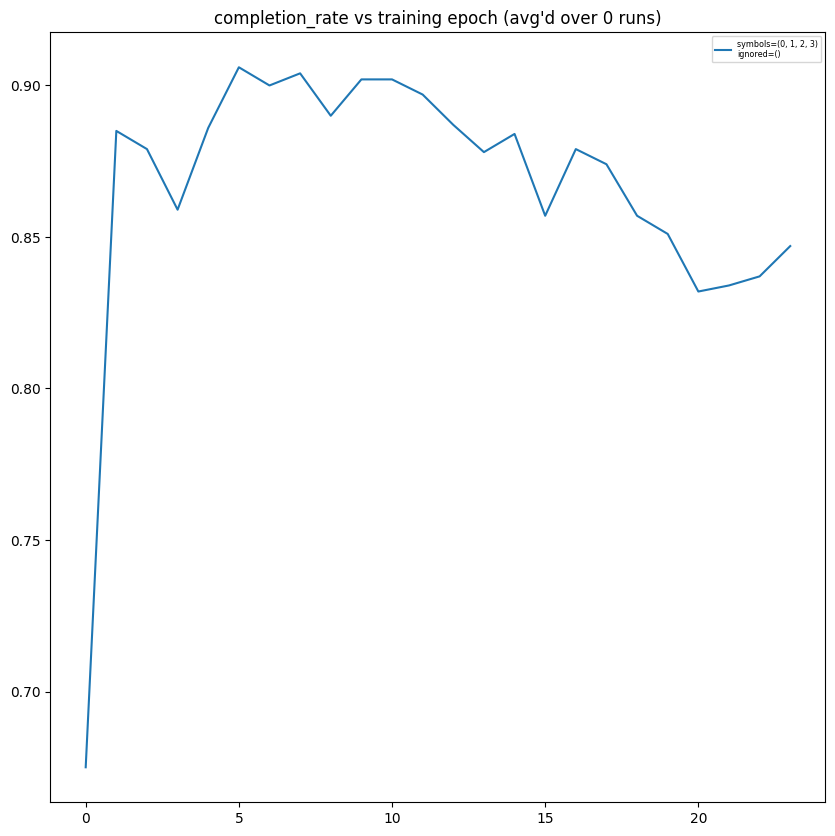

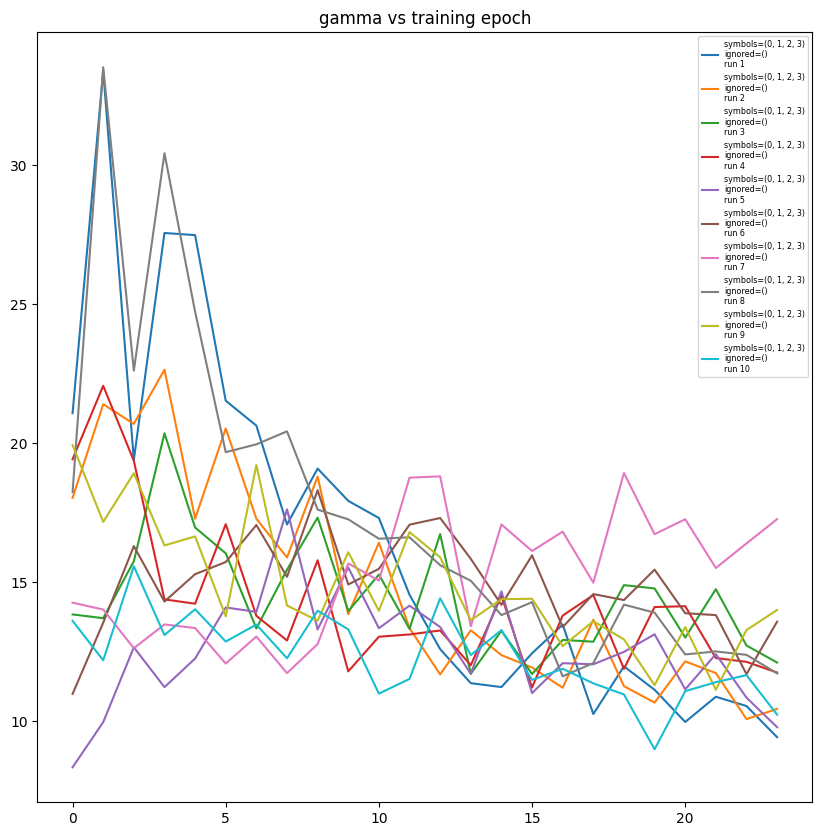

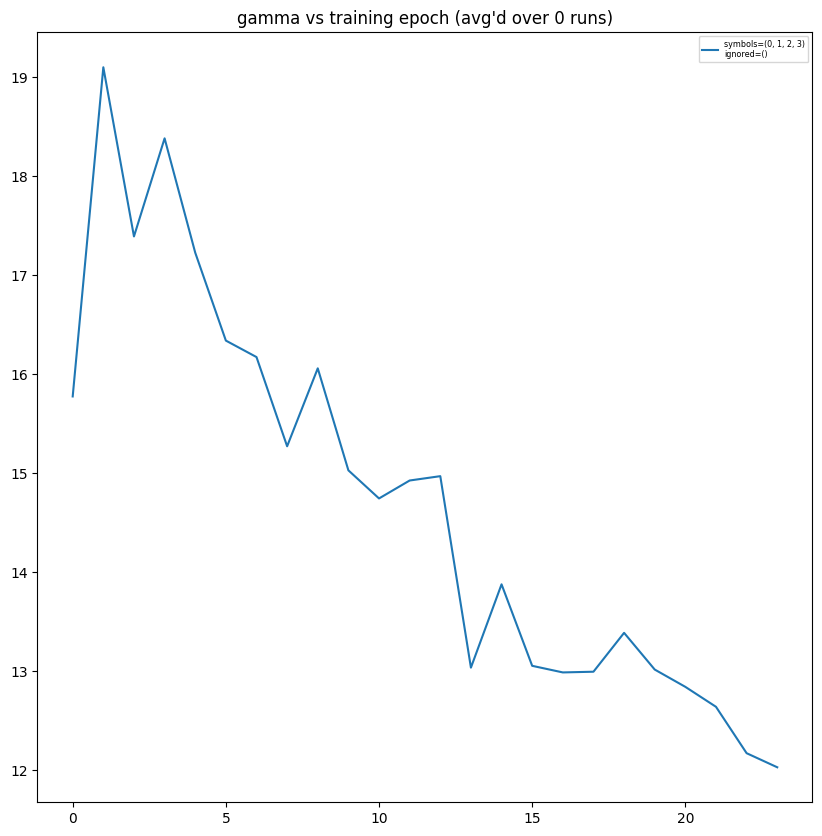

final state
 [(0, 1, 3), (2,)]
saving normalized_singleExp_longRun_3.pkl


In [3]:
#####################################
### Run Experiment to Train Model ###
#####################################

from experiments import run_experiment_new

name = 'normalized_singleExp_longRun_3'#'normalized'
spec = {'symbols': [(0,1,2,3), (0, 1, 3), (1, 2, 3), (1, 3)],
        'ignored': [(), (2,), (0,), (0, 2)]}
#n_runs = [1, 1, 1, 0]
n_runs = [10, 0, 0, 0]
exp=run_experiment_new(data, spec, plot=True, n_runs=n_runs, fname=name, save=True)

In [4]:
#######################
### Save Experiment ###
#######################

save_name = name
save_experiment(save_name, exp)

saving normalized_singleExp_longRun_3.pkl


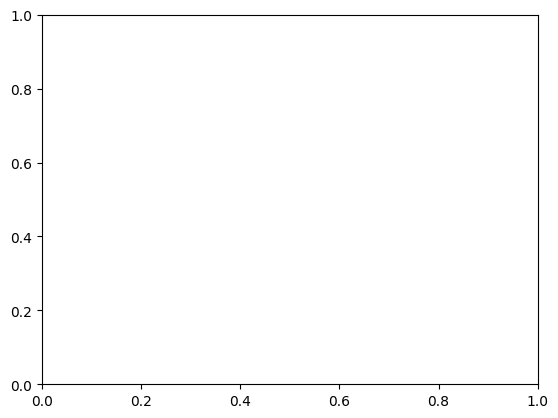

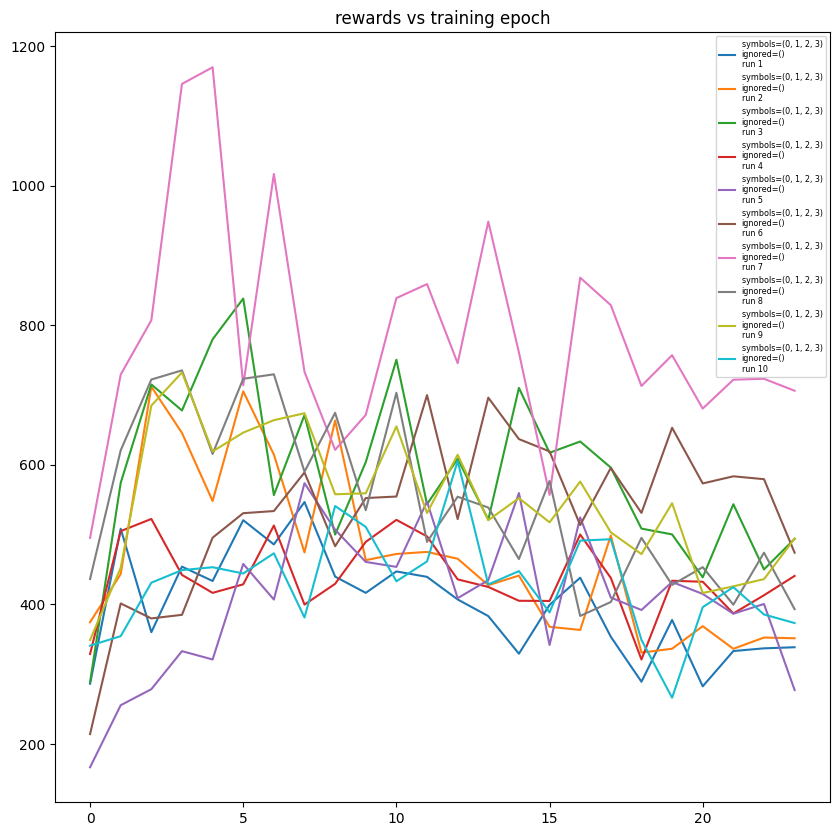

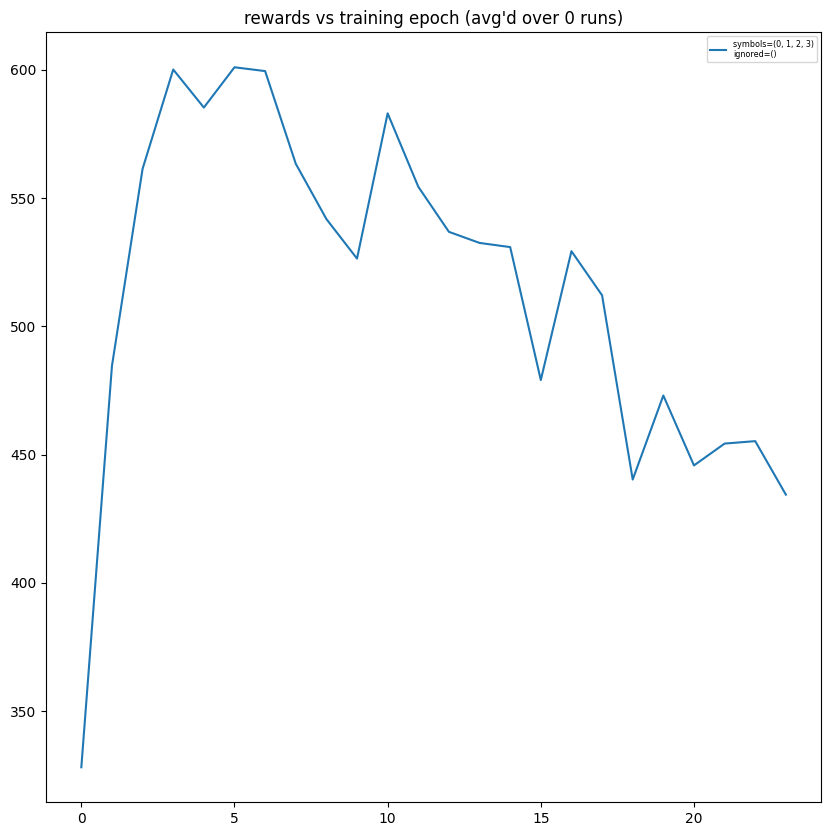

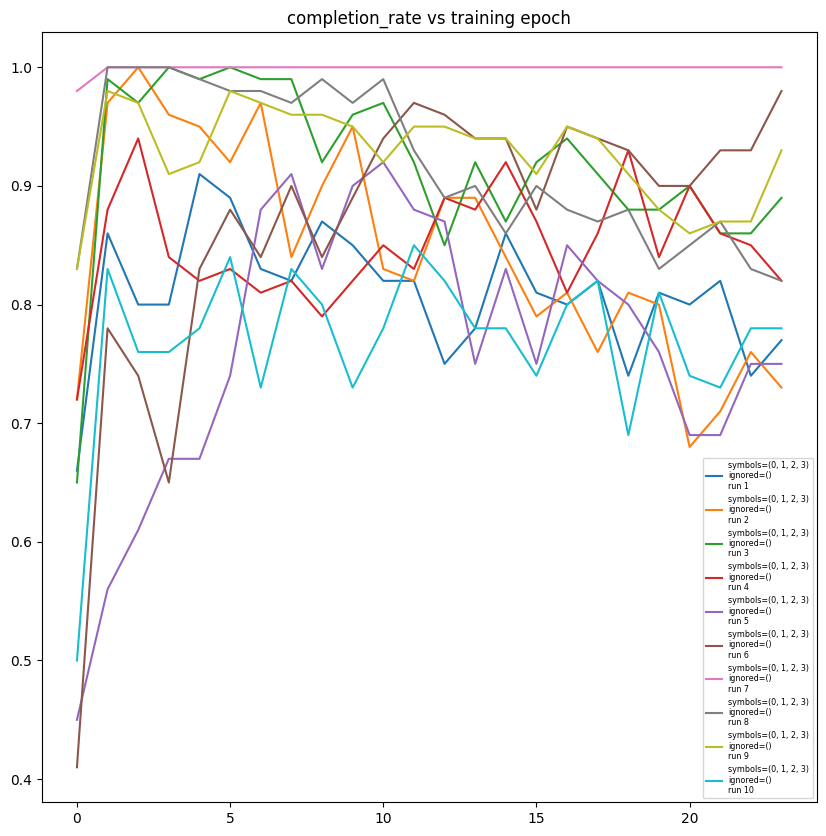

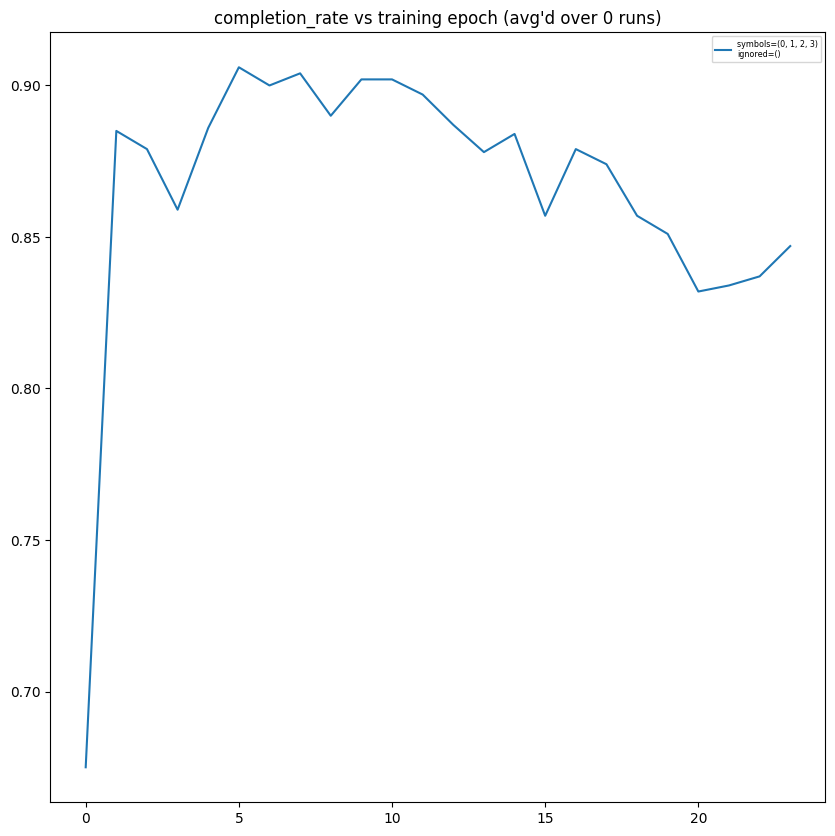

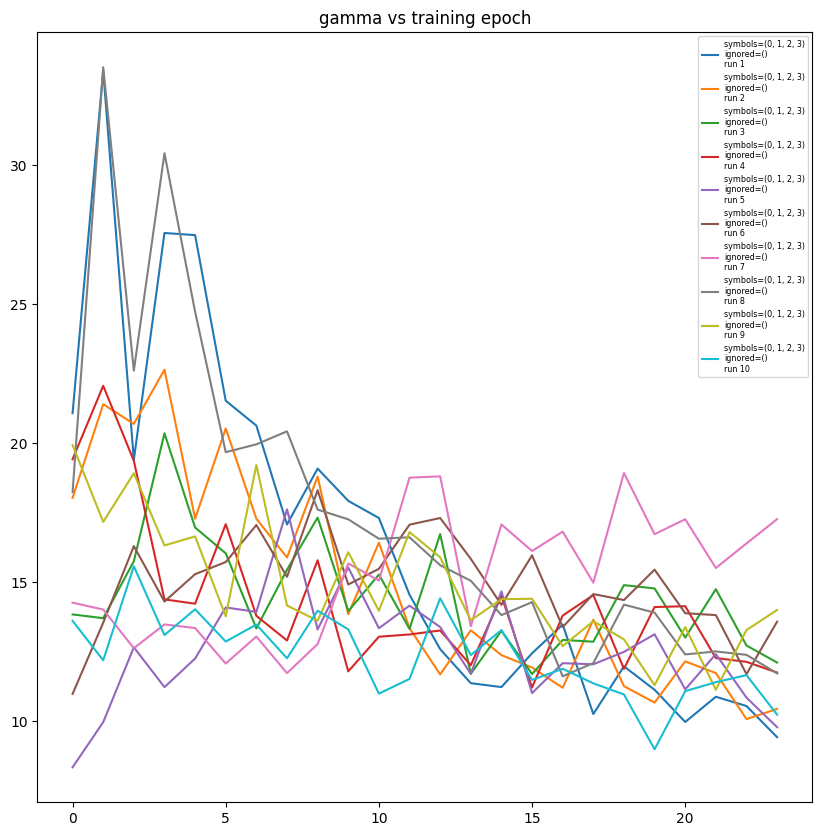

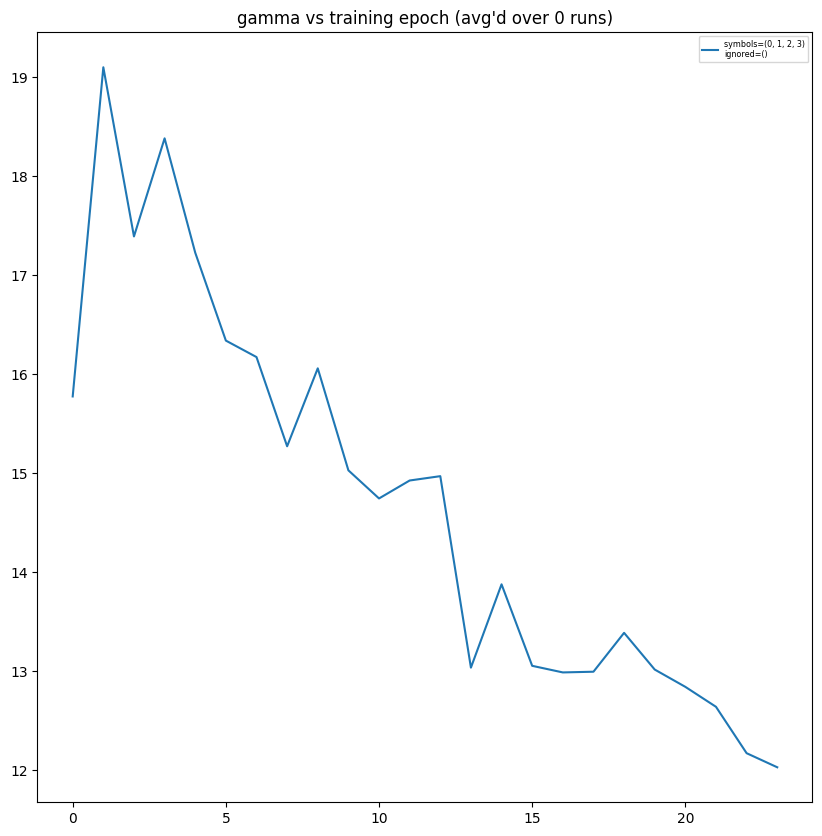

In [5]:
#######################
### Load Experiment ###
#######################

#name = 'reference_model'
#name = 'normalized_singleExp_longRun_2'
exp = load_experiment(name)
plot_experiment_new(exp)

In [129]:
###############################
### Choose Model Checkpoint ###
###############################

config_idx = 0
run_idx = 7

best_model_idx = np.argmax(exp['completion_rate'][config_idx][1][run_idx])
#best_model_idx = np.argmin(exp['gamma'][config_idx][1][run_idx])
#best_model_idx = 90 #-1

ae = exp['ae_list'][config_idx][1][run_idx][best_model_idx]
fdyn = exp['fdyn_list'][config_idx][1][run_idx][best_model_idx]
ae.encode(torch.tensor([0.,0.,0.,0.]))

tensor([-0.0011, -0.0018], device='cuda:0', grad_fn=<ViewBackward0>)

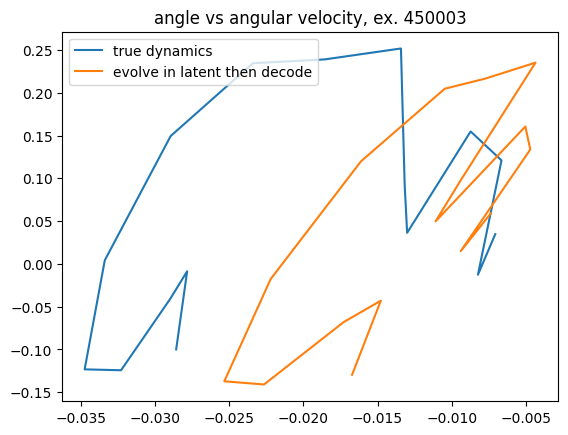

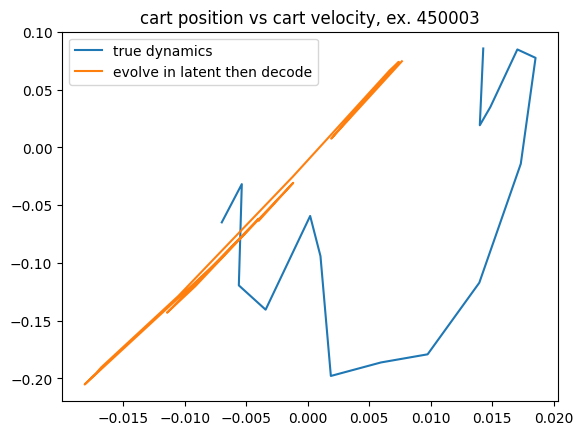

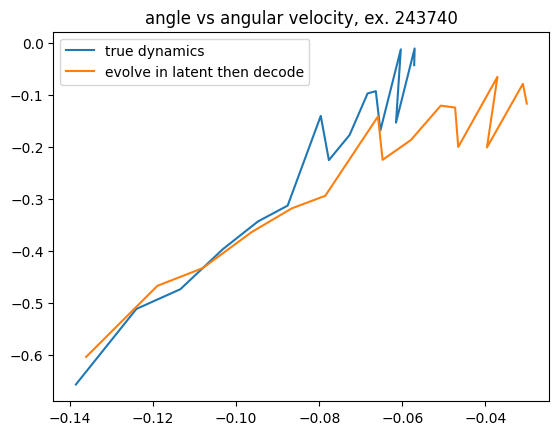

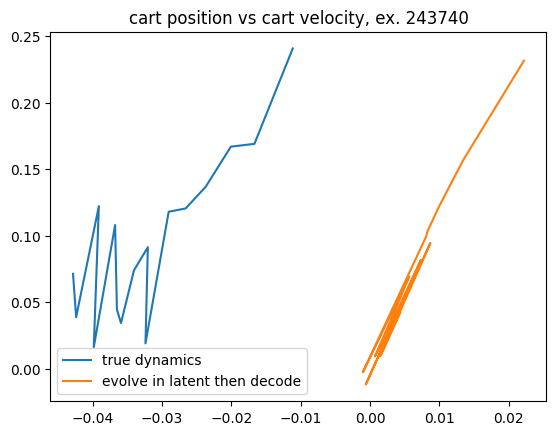

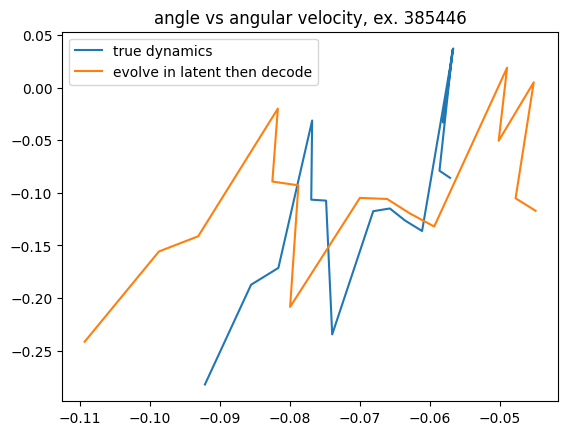

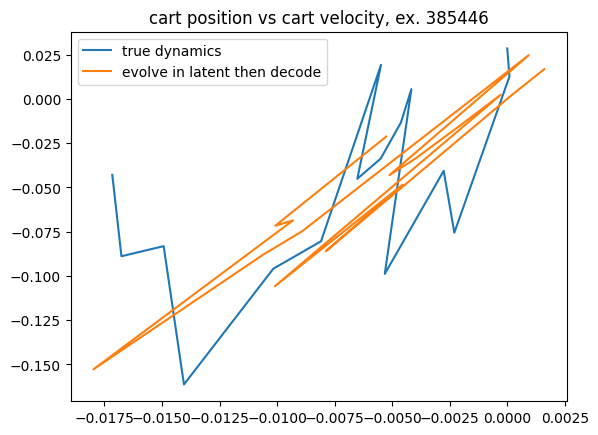

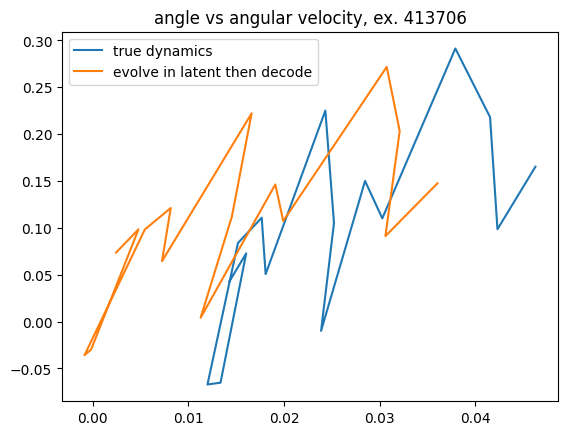

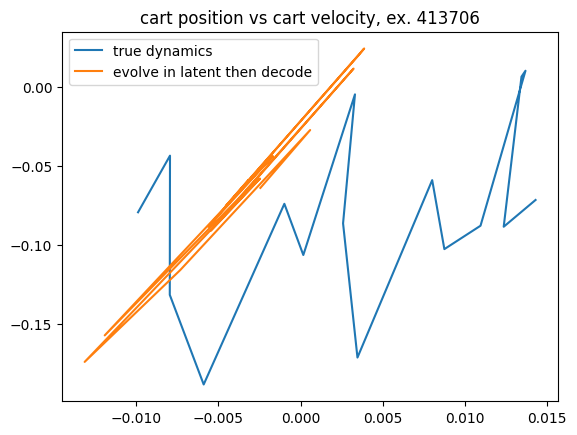

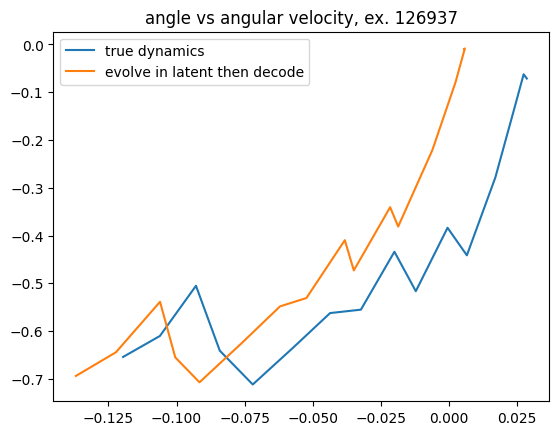

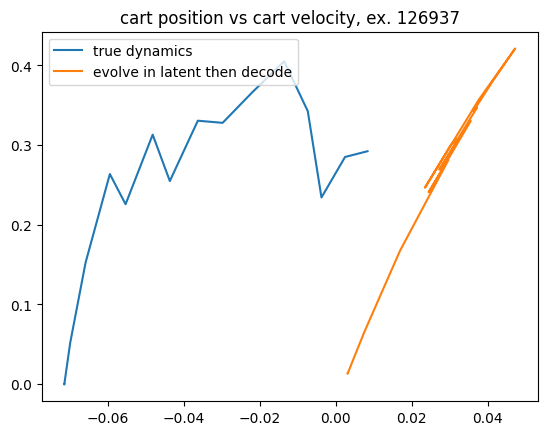

In [130]:
#######################################
### Plot Reconstructed Trajectories ###
#######################################

plot_trajectories(ae, fdyn, Xtest[0], Utest[0], 5, steps=params.traj_len)

z_eq tensor([[-0.0011, -0.0018]], device='cuda:0', grad_fn=<AddmmBackward0>)


100%|██████████| 500/500 [00:58<00:00,  8.59it/s]


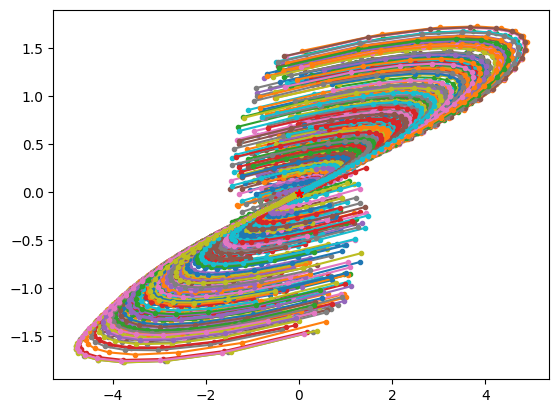

100%|██████████| 500/500 [00:51<00:00,  9.71it/s]


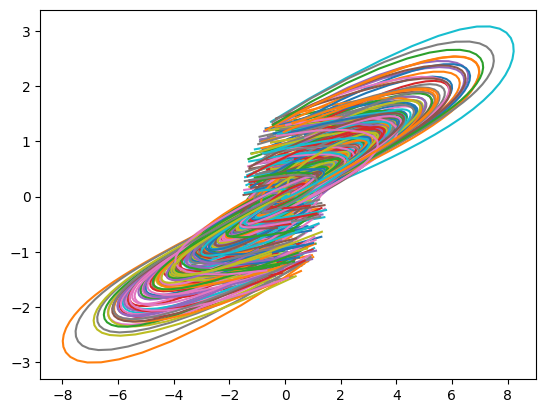

max x: 1.9504473596927328
max v: 2.0362611962459334
max theta: 0.8741544485092163
max w: 2.381943571968923


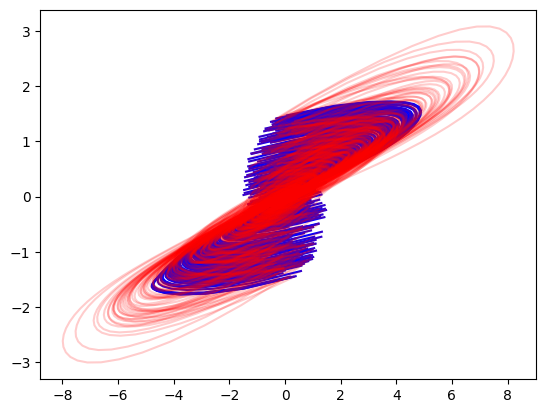

x data (500, 301, 4)
z data (500, 301, 2)
z proj data (500, 301, 2)
u data (500, 300, 1)
gamma forward 1.1466002
gamma backward 2.2154155


In [131]:
####################################
### Initialize Data for Lyapunov ###
####################################

from plotting import plot_latent_trajectories
from utils import rollout_trajectories

r = 1.2e-1
r_test = r 
rz_init = 1.50 
n_traj = 500 #3000 
T = 300
b = ae.encode(torch.tensor(4*[0.,])).cpu().detach().numpy()

for u_cost in [1]:
    lqr = LQR(ae, fdyn, u_cost=u_cost)
    pts, z_data, x_init_cond = plot_latent_trajectories(ae, fdyn, rz_init, n_traj, T=T, plot_quadratic=False, origin_spec=(b, r), lqr=lqr) #r=0.05
    x_data, z_proj_data, u_data, gammas = rollout_trajectories (ae, fdyn, lqr, x_init_cond, plot=True, n_traj=n_traj, T=T)
    gamma_fwd, gamma_bwd = gammas
    
    for zi in z_data:
        plt.plot(zi[:,0], zi[:,1], 'b-')
    for zi in z_proj_data:
        plt.plot(zi[:,0], zi[:,1], 'r-', alpha=0.2)
    plt.show()
    
    u_data = u_data[...,np.newaxis]
    
    print("x data", x_data.shape)
    print("z data", z_data.shape)
    print("z proj data", z_proj_data.shape)
    print("u data", u_data.shape)
    print("gamma forward", gamma_fwd)
    print("gamma backward", gamma_bwd) 

In [132]:
from utils import rollout_parallel_rk4

_ = rollout_parallel_rk4(ae, fdyn, lqr, x_init_cond)

100%|██████████| 200/200 [00:00<00:00, 697.50it/s]


z_eq: tensor([-0.0011, -0.0018], device='cuda:0', grad_fn=<ViewBackward0>)
pd loss: False
dyn loss: True
lb loss False
grad loss False
rho: 0.85
c lb 0.1
l_dyn 1
l_pd 1
l_lb 1
l_grad 1e-06
using grid data, grid_density: 100
features: 256
coeff: 0.1
LyapunovGeneral(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=256, bias=False)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=False)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=1, bias=False)
  )
)
it 0: tensor([191.5945], device='cuda:0', grad_fn=<AddBackward0>)
it 1000: tensor([1.7444], device='cuda:0', grad_fn=<AddBackward0>)
it 2000: tensor([0.0272], device='cuda:0', grad_fn=<AddBackward0>)
it 3000: tensor([0.0010], device='cuda:0', grad_fn=<AddBackward0>)
it 4000: tensor([0.0001], device='cuda:0', grad_fn=<AddBackward0>)
alpha 86.65339660644531
torch.Size([150500, 2])
Lipschitz constant tensor(103.3409, device='cuda:0', grad_fn=<MaxBackward1>)


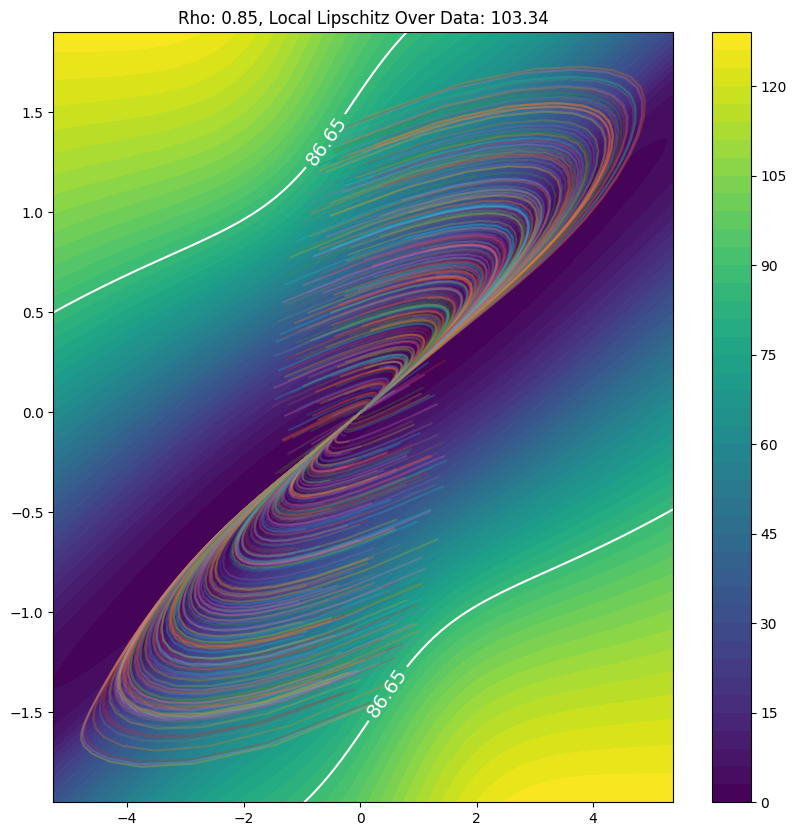

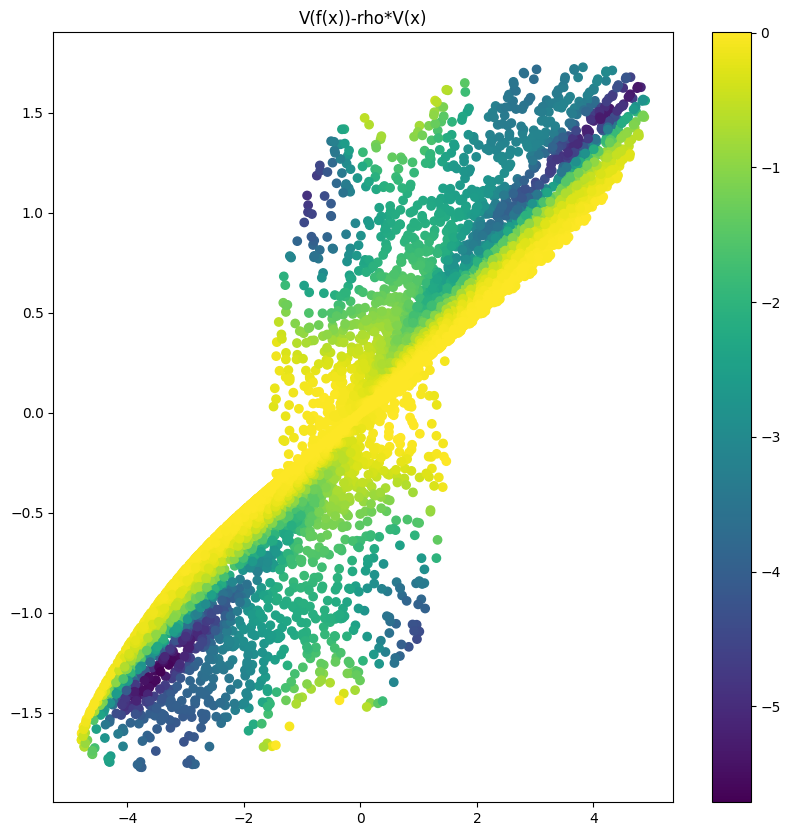

In [133]:
###############################
### Learn Lyapunov Function ###
###############################

from controls import mlp_lyapunov_reparam
from experiments import load_experiment
from theorem_tools import plot_violation

z_eq = ae.encode(torch.tensor([0.,0.,0.,0]).float())
print("z_eq:", z_eq)
rho = 0.85 
features = 256
parameterization = "general" 
lyap_training_epochs = int(5e3) #3e4
V, rho, alpha, lip = mlp_lyapunov_reparam(z_data, epochs=lyap_training_epochs, lr=2e-4, grid_dens=100, rho=rho, z_eq=z_eq, parameterization=parameterization, features=256) #ep 0.5e4
plot_violation(V, rho, torch.tensor(z_data), ae, lip.item(), gamma_fwd, alpha/6, plot_contours=False)

100%|██████████| 295/295 [00:52<00:00,  5.58it/s]


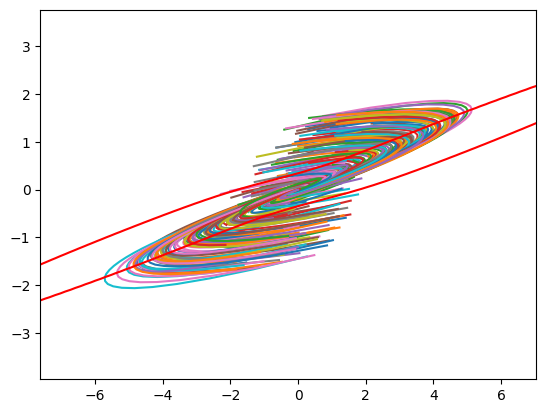

max x: 0.8079880940611414
max v: 1.0769769995182579
max theta: 0.4705857038497925
max w: 1.4711137336869748
(295, 101, 4)


In [134]:
##############################################
### Compute Skeleton of Invariant Manifold ###
##############################################

from theorem_tools import compute_preimage, plot_lyapunov_lvlsets, verify_invariance

#manifold_initial_conditions = compute_preimage(ae, z_data, 0.50, 14, uniform_sampling=True) 
manifold_initial_conditions = compute_preimage(ae, z_data, 0.50, 5, uniform_sampling=True) 
a0_manifold = torch.max(V(ae.encode(torch.tensor(manifold_initial_conditions)))).cpu().item()

# n_traj doesn't do anything here, only the grid resolution in the previous step influences the number of trajectories (one per each grid point)
manifold, _, _, _, _, _ = rollout_trajectories(ae, fdyn, lqr, manifold_initial_conditions, n_traj=500, T=100, V=V, a0=a0_manifold/6, n_per_axis=100)
print(manifold.shape)

In [135]:
############################################################
### Compute Preimage by Sampling from Invariant Manifold ###
############################################################

#Dx = compute_preimage(ae, z_data, 0.75, 7, uniform_sampling=True, X=manifold, n_samples=int(4e4), eps=0.01) # n_samples=1e4, eps=0.01
Dx = compute_preimage(ae, z_data, 0.75, 7, uniform_sampling=True, X=manifold, n_samples=int(300), eps=0.01) # n_samples=1e3, eps=0.01

(298, 4)


100%|██████████| 10/10 [00:33<00:00,  3.32s/it]


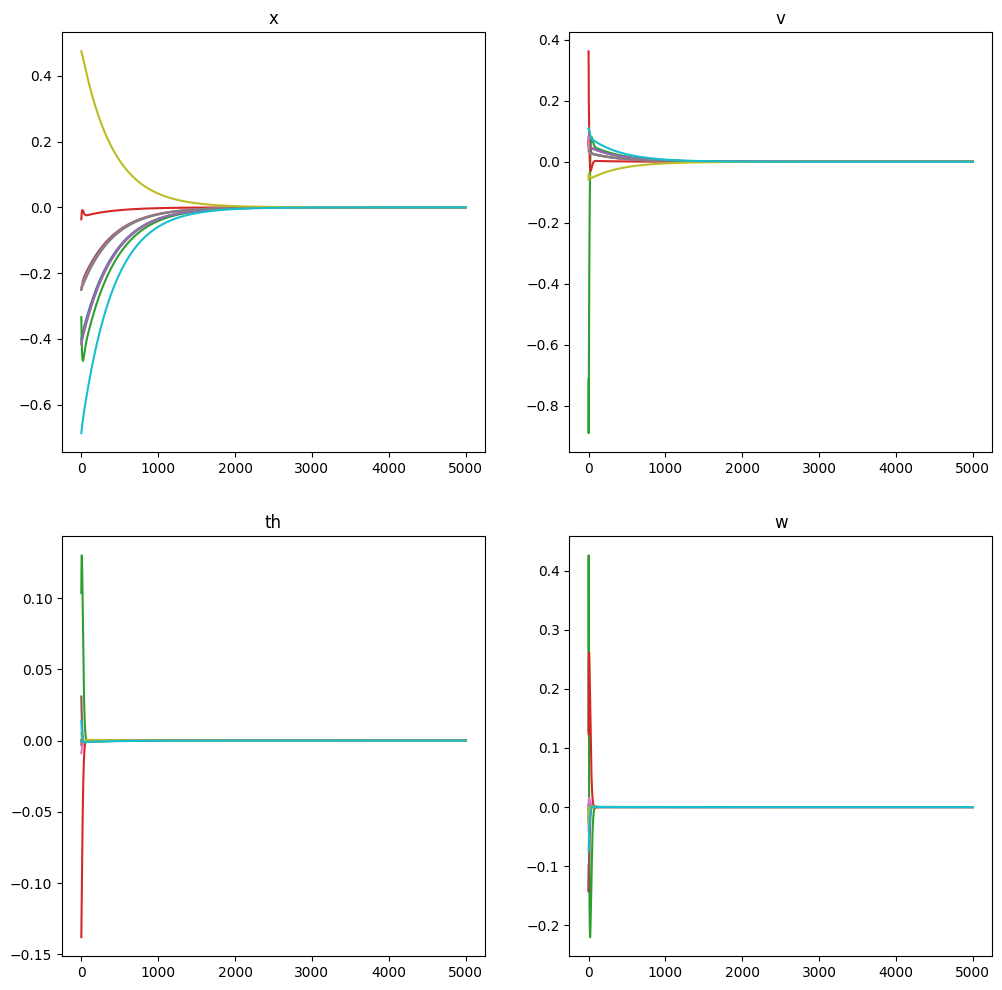

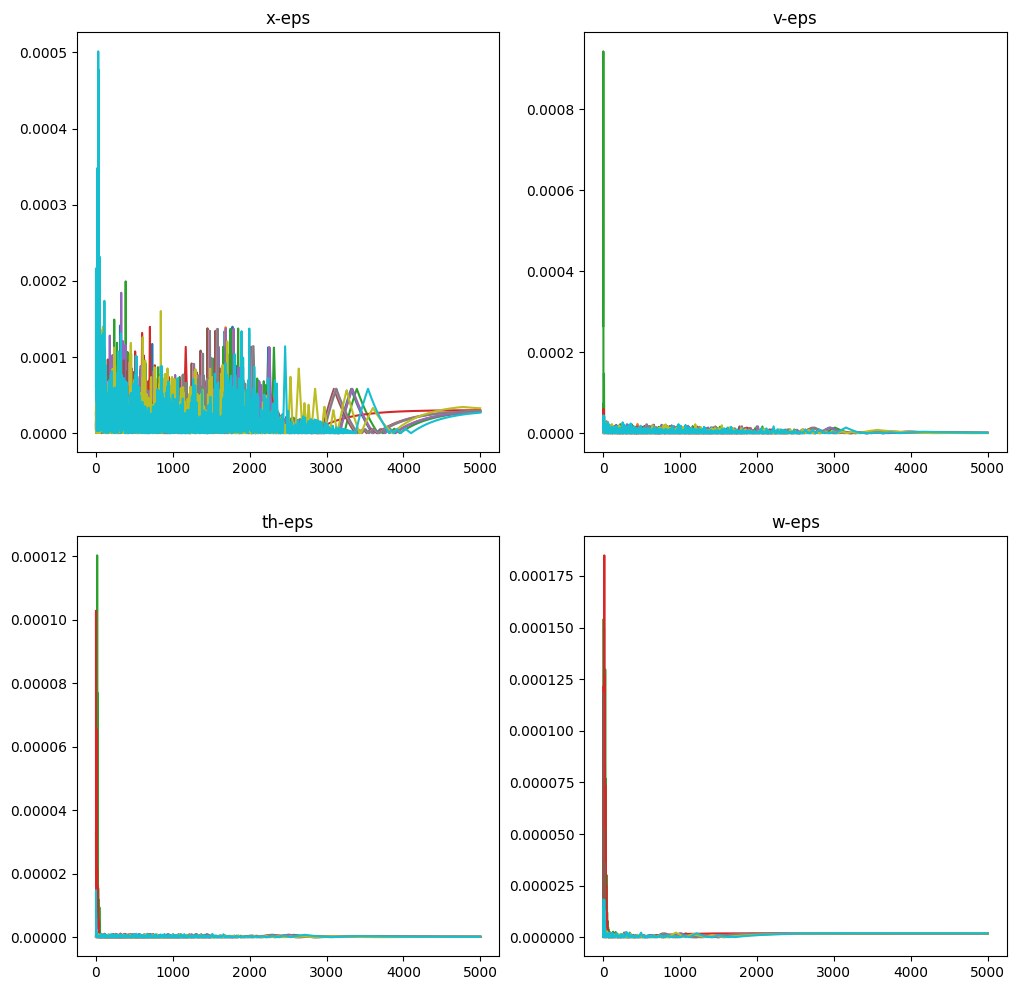

In [136]:
################################################
### Inspect Invariance of Invariant Manifold ###
################################################

print(Dx.shape)
#_ = verify_invariance(ae, fdyn, T=60, stabilize=True, X0=Dx[0:250], manifold=manifold)
_ = verify_invariance(ae, fdyn, T=5000, stabilize=True, X0=Dx[0:10], manifold=manifold)

(298, 4)
47.9144401550293
k_eval: [  2   3   4   5   6   7   8   9  10 200]


  0%|          | 0/285 [00:00<?, ?it/s]/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
100%|██████████| 285/285 [02:15<00:00,  2.10it/s]


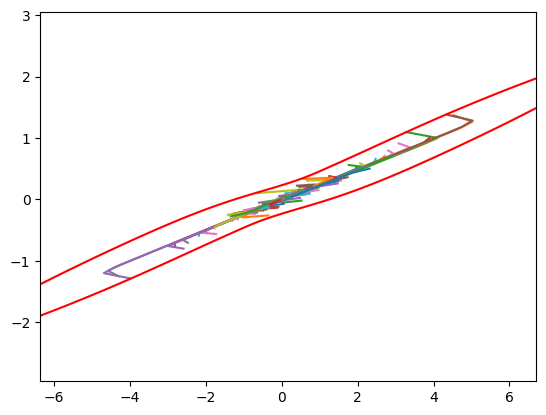

max x: 0.735026085539356
max v: 1.0188834998514058
max theta: 0.14596734941005707
max w: 1.0892247086997286
gamma fwd: 0.08577791
L: 15.40121078491211
a0: 7.985740025838216
rho: 0.85
Ly/(1-p): 8.807224
R: 0.22800755500793457
k: [  2   3   4   5   6   7   8   9  10 200]
gamma_k forward: [0.18877392 0.38672325 0.5266707  0.5616166  0.53916806 0.494947
 0.44260815 0.47060075 0.50754046 0.08723255]
Ly_k/(1-p^k): [10.476926   15.43506713 16.96960739 15.54854905 13.33199676 11.2194961
  9.36991427  9.4325627   9.73289569  1.34348679]
xticks arg 1 [ 0  1  2  3  4  5  6  7  8  9 10]
mid [  2   3   4   5   6   7   8   9  10 200]
xticks arg 2 [1, np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(200)]


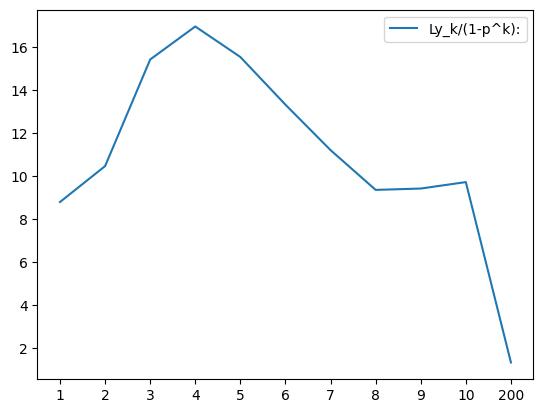

100%|██████████| 298/298 [01:46<00:00,  2.80it/s]


max x: 0.735026085539356
max v: 1.0389324810510667
max theta: 0.23200863599777222
max w: 1.3639866839391566


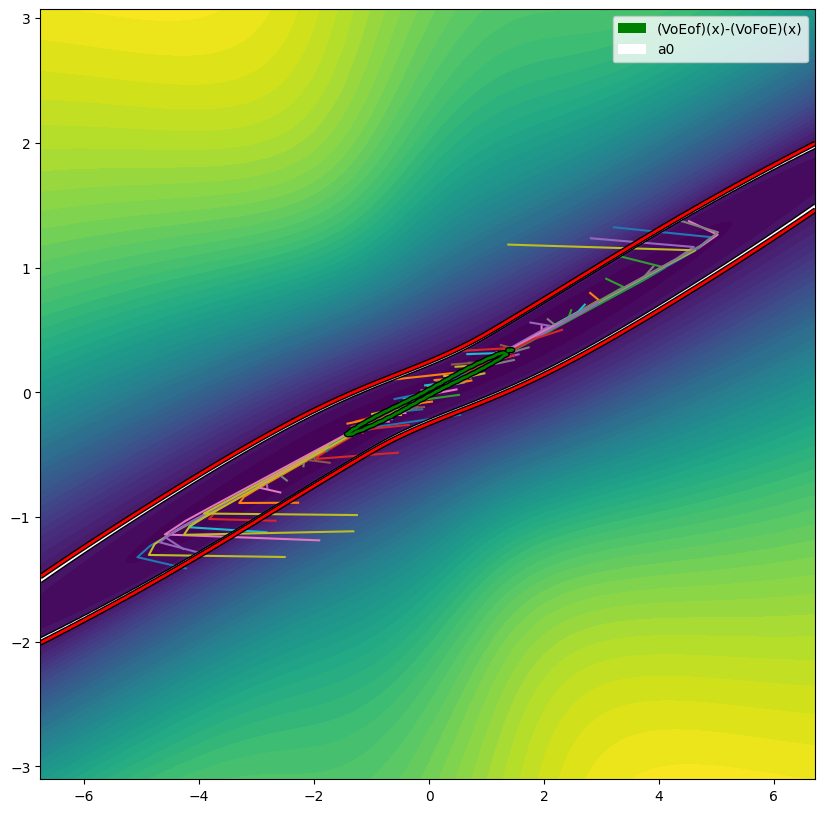

In [137]:
##################################################################
### Compute Ly/p and Levelsets over Trajectories from Preimage ###
##################################################################

a0 = torch.max(V(ae.encode(torch.tensor(Dx)))).cpu().item()
print(Dx.shape)
print(a0)
Dz = z_data
#Dxtraj, gamma, L, res = plot_lyapunov_lvlsets(V, ae, fdyn, Dx, Dz, a0/6, rho, only_rollout=False, n_per_axis=175)
Dxtraj, gamma, L, res = plot_lyapunov_lvlsets(V, ae, fdyn, Dx, Dz, a0/6, rho, only_rollout=False, n_per_axis=175)

ValueError: Contour levels must be increasing

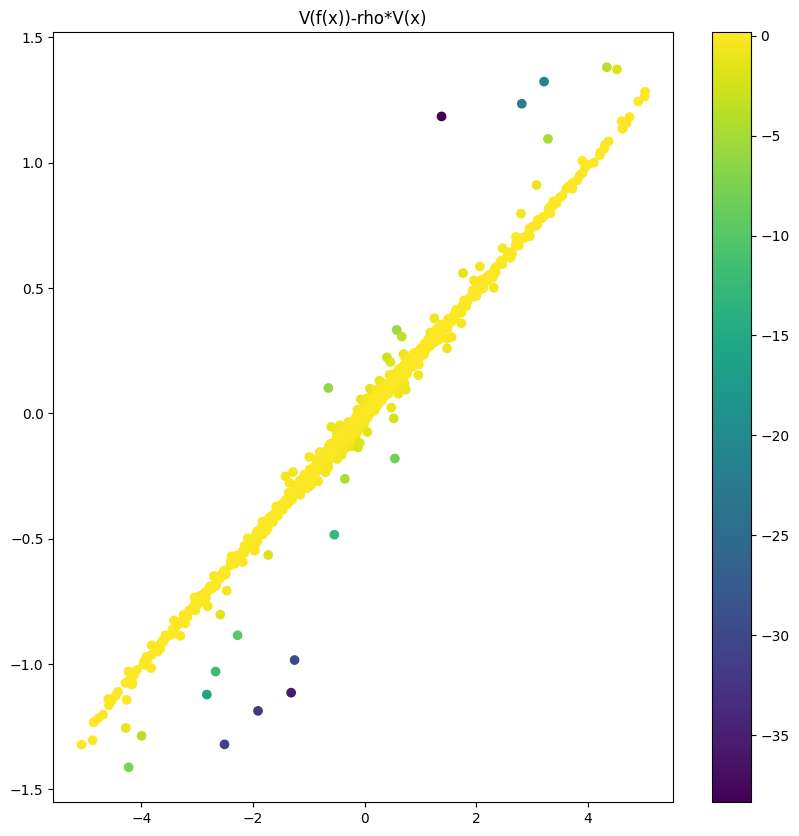

In [138]:
##################################################################
### Plot Violation of Lyapunov Condition for E(x) Trajectories ###
##################################################################

from theorem_tools import plot_violation, verify_invariance
plot_violation(V, rho, torch.tensor(Dxtraj), ae, gamma, L, a0/6) #a0/6

100%|██████████| 4/4 [00:00<00:00,  5.92it/s]


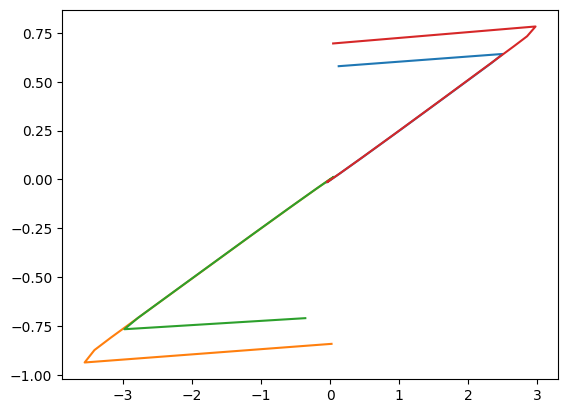

max x: 0.14325852297893407
max v: 0.5922462628403647
max theta: 0.15
max w: 0.9379614727698203


100%|██████████| 3500/3500 [00:05<00:00, 625.82it/s]


x-theta traj: (4, 501, 4)


100%|██████████| 15000/15000 [00:02<00:00, 5134.94it/s]
/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


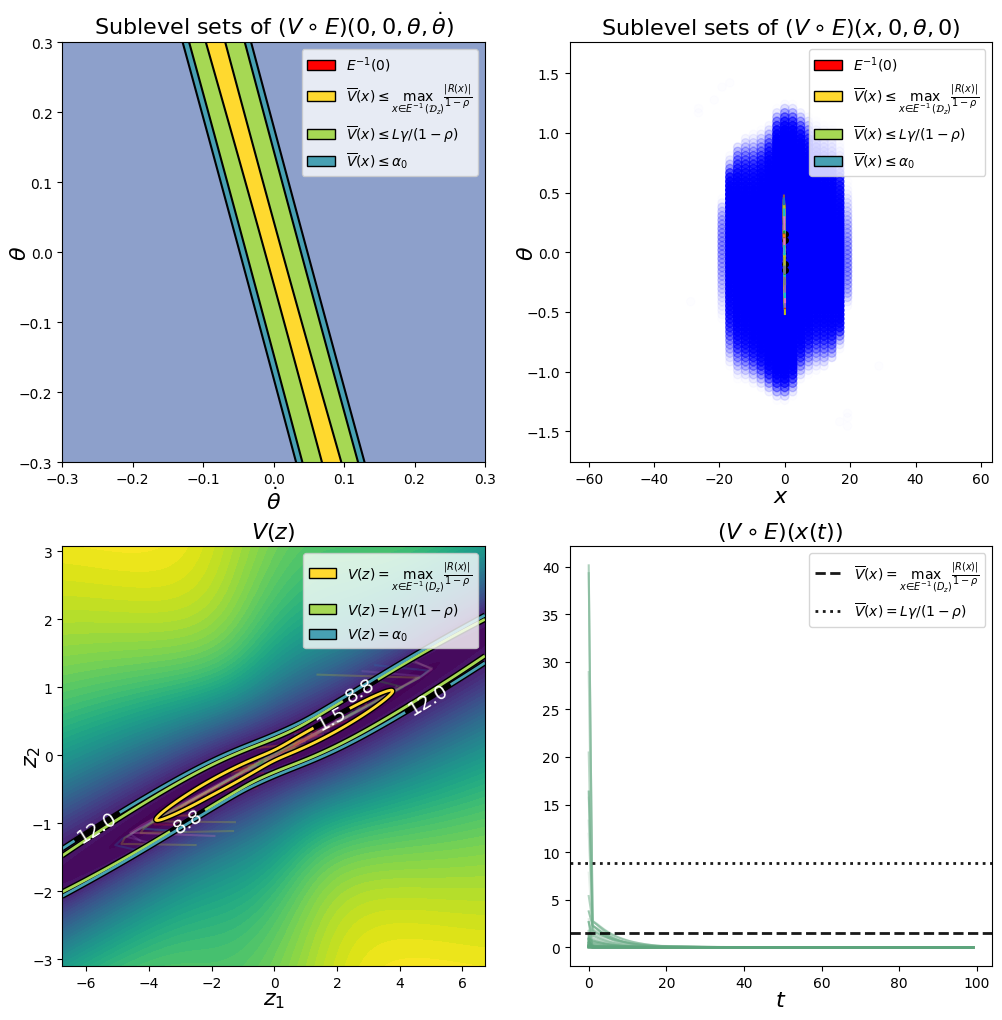

In [139]:
###################
### Make Figure ###
###################

from plotting import plot_lyapunov_slice
from theorem_tools import plot_figure_final
from utils import rollout_trajectories

lqr = LQR(ae, fdyn)

#r_plot = 0.2 
r_plot = 0.3
X0_extra = np.array([[-0.05, 0.05, -0.1, 0.0],
                     [-0.075, -0.1, 0.15, 0.05],
                     [0.0, 0.0, 0.1, 0.0],
                     [0.0, 0.1, -0.15, 0.05]])

X_extra, _, _, _ = rollout_trajectories(ae, fdyn, lqr, X0_extra, T=500) #T=2000
#X_extra, _, _, _ = rollout_trajectories(ae, fdyn, lqr, Dx[:1000], T=500)
#plot_figure_final(V, ae, Dxtraj, 2*[r_plot], 2*[r_plot], res/(1-rho), a0/6, (L*gamma/(1-rho)).item(), n_per_axis=500, xth_traj=X_extra)
plot_figure_final(V, ae, Dxtraj, 2*[r_plot], 2*[r_plot], res/(1-rho), a0/6, (L*gamma/(1-rho)).item(), n_per_axis=500, xth_traj=X_extra,
                  roa=[60, 1, 1.6, 1], roa_per_axis=[90, 12, 90, 12], fdyn=fdyn, lqr=lqr, n_chunks=50, X_test=Xtest[0])

In [93]:
import gc
gc.collect()

997637

100%|██████████| 250/250 [00:00<00:00, 695.65it/s]


torch.Size([1000, 251, 4])


/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


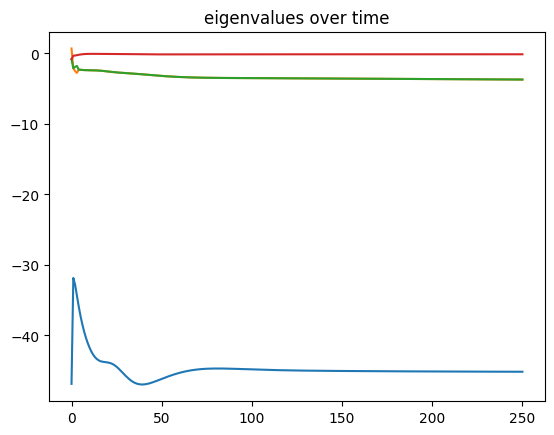

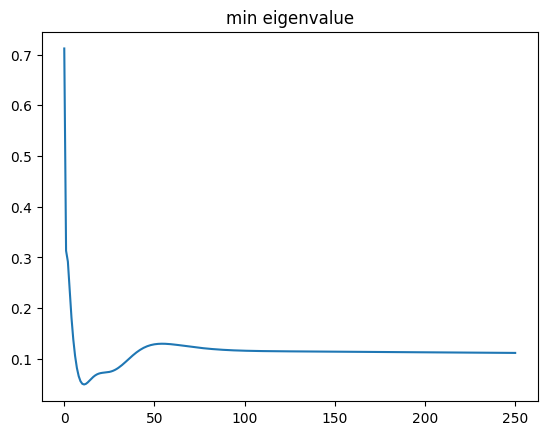

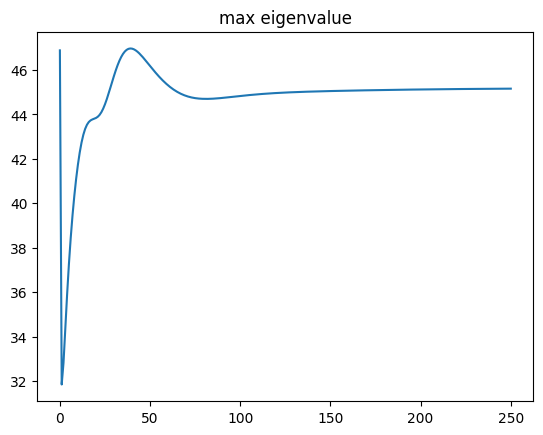

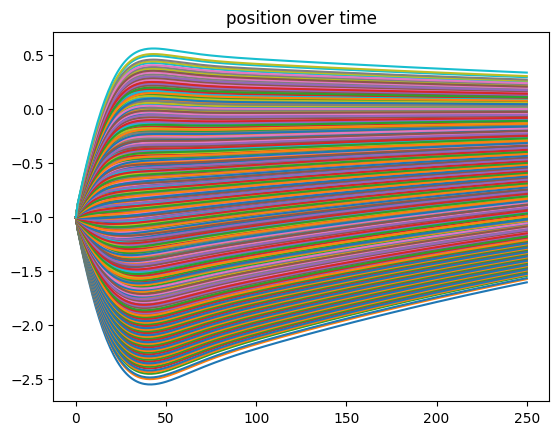

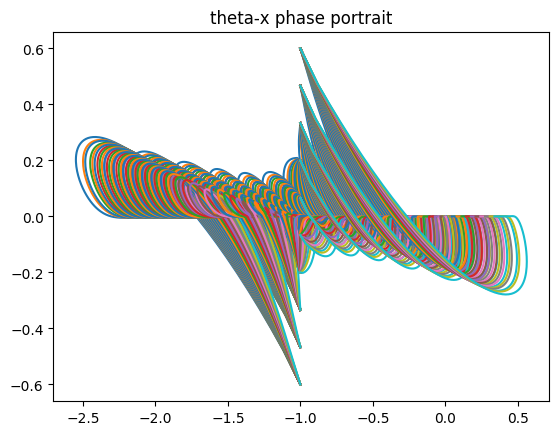

100%|██████████| 250/250 [00:00<00:00, 697.34it/s]


torch.Size([1000, 251, 4])


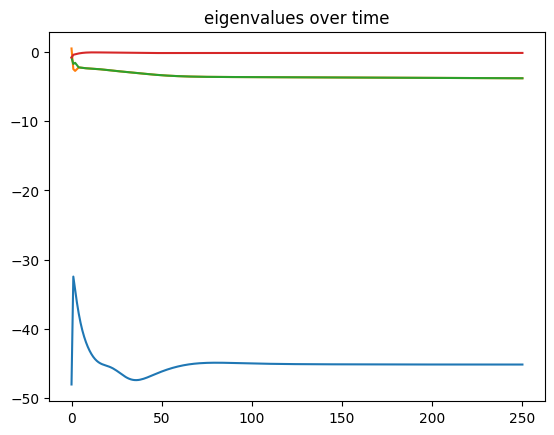

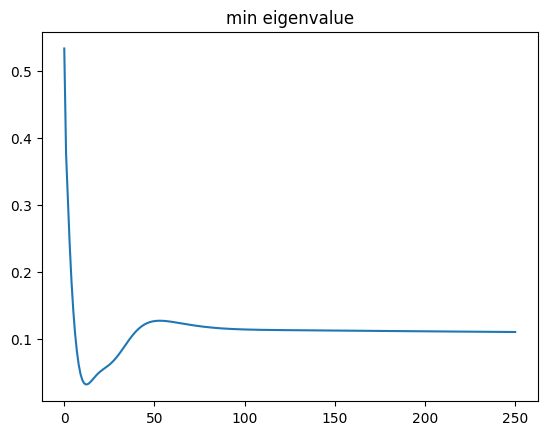

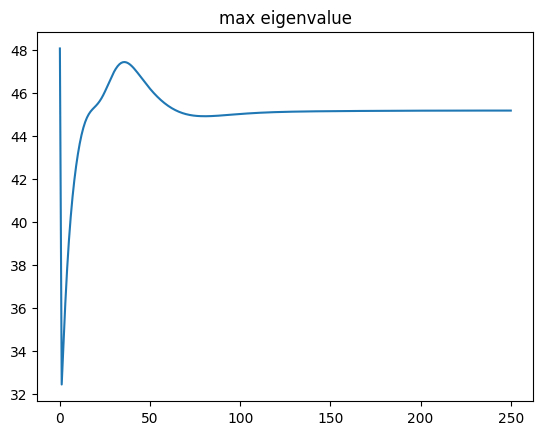

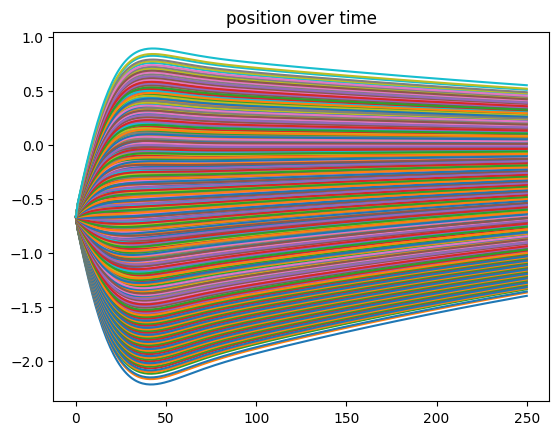

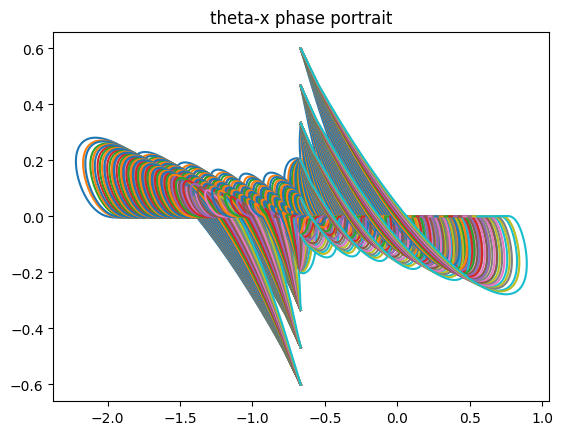

100%|██████████| 250/250 [00:00<00:00, 699.83it/s]


torch.Size([1000, 251, 4])


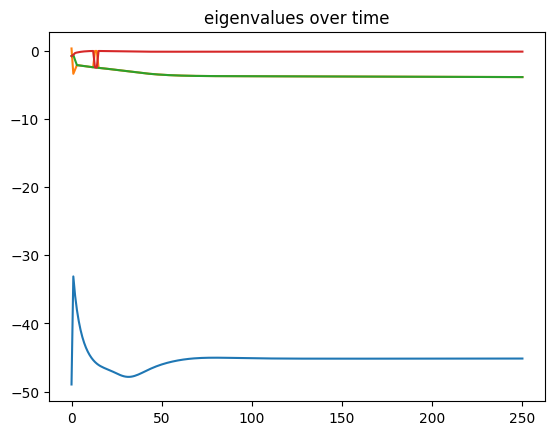

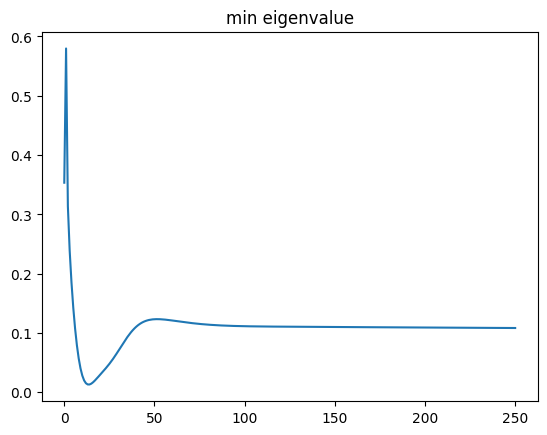

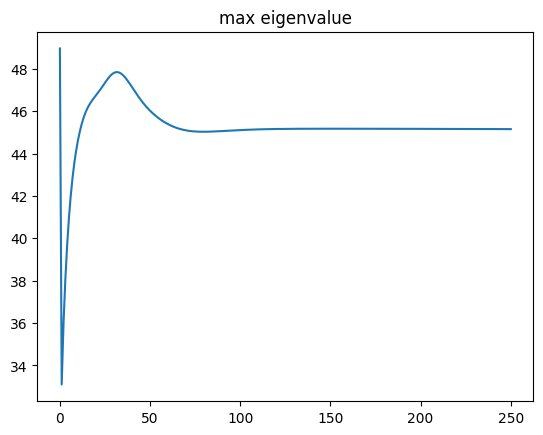

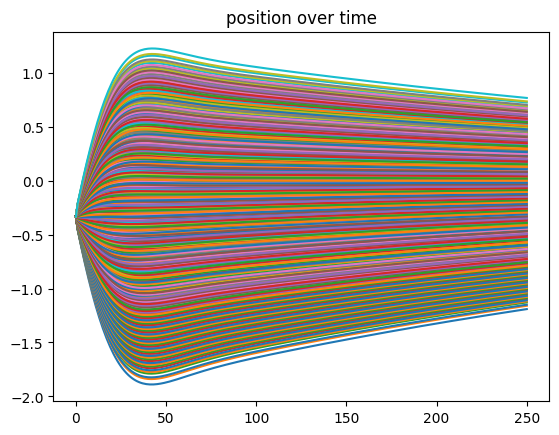

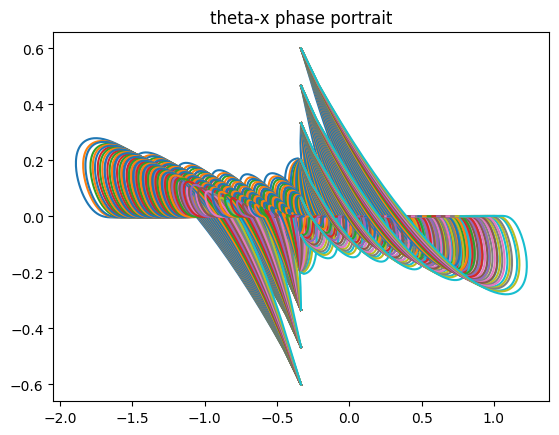

100%|██████████| 250/250 [00:00<00:00, 698.26it/s]


torch.Size([1000, 251, 4])


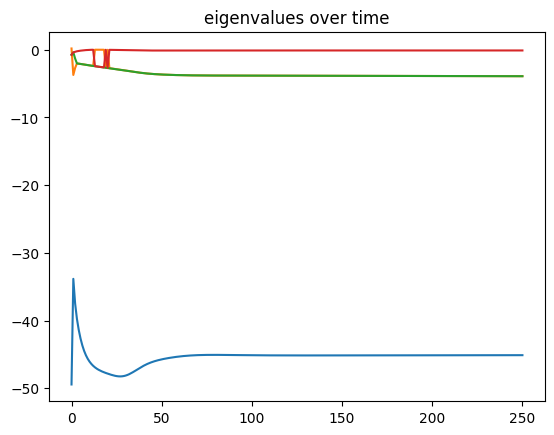

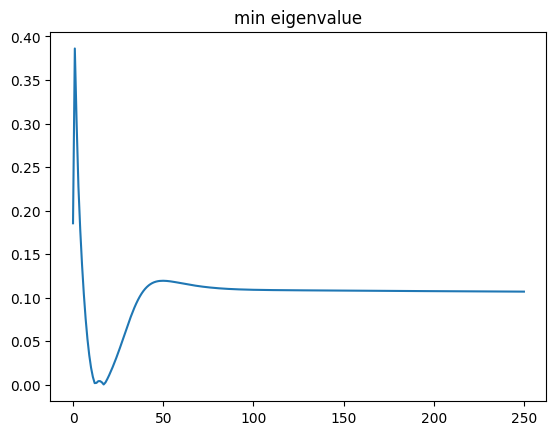

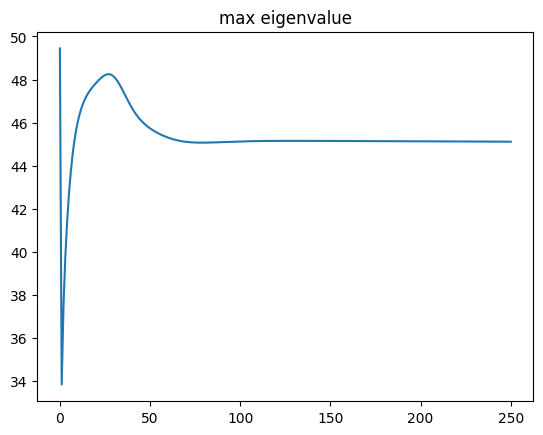

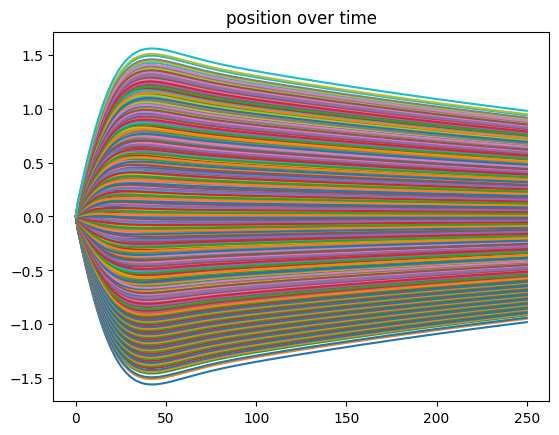

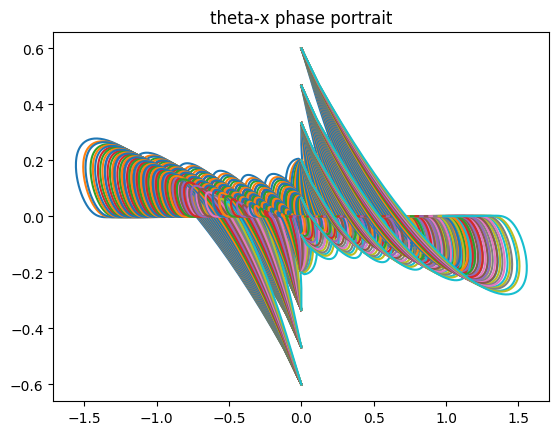

100%|██████████| 250/250 [00:00<00:00, 694.98it/s]


torch.Size([1000, 251, 4])


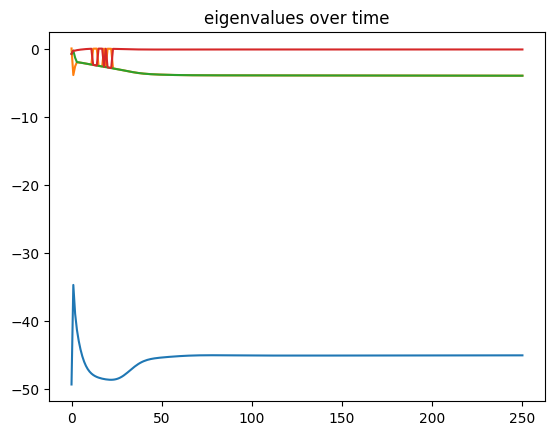

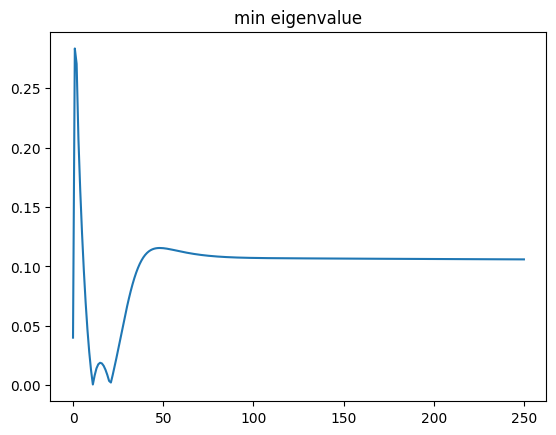

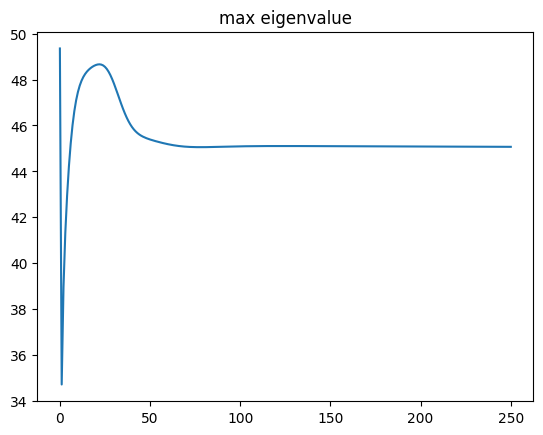

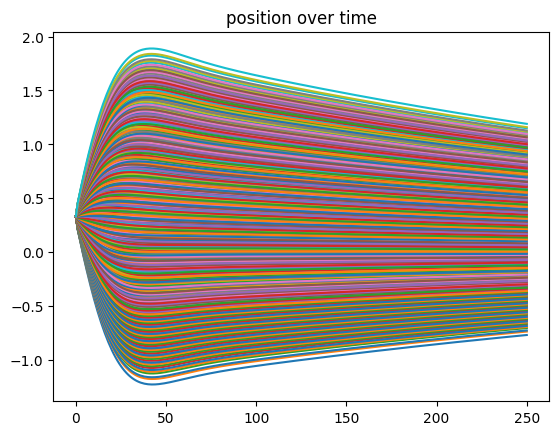

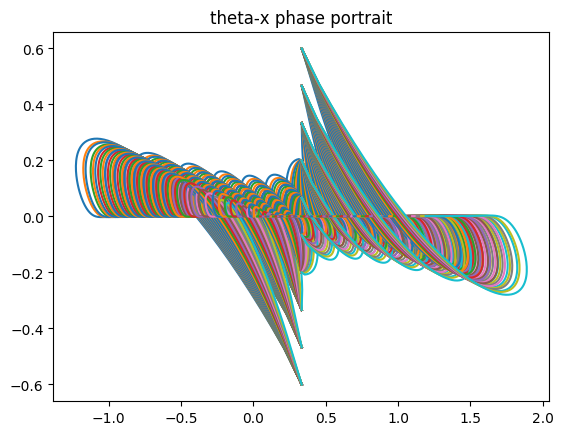

100%|██████████| 250/250 [00:00<00:00, 692.29it/s]


torch.Size([1000, 251, 4])


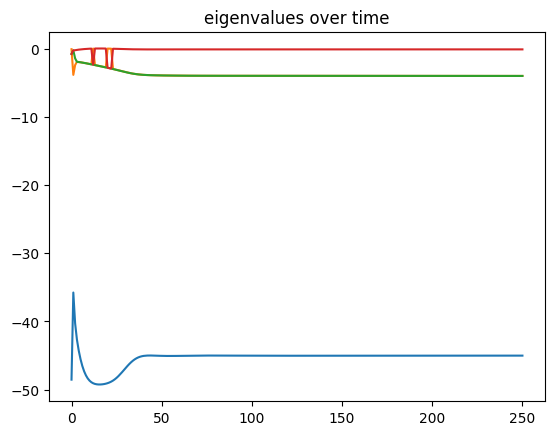

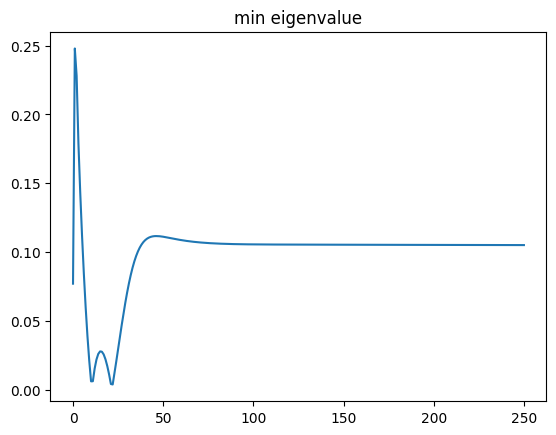

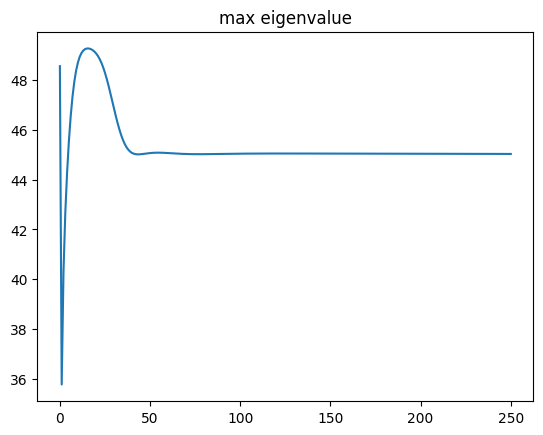

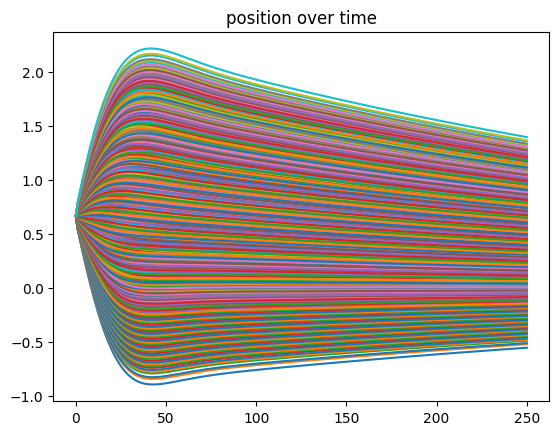

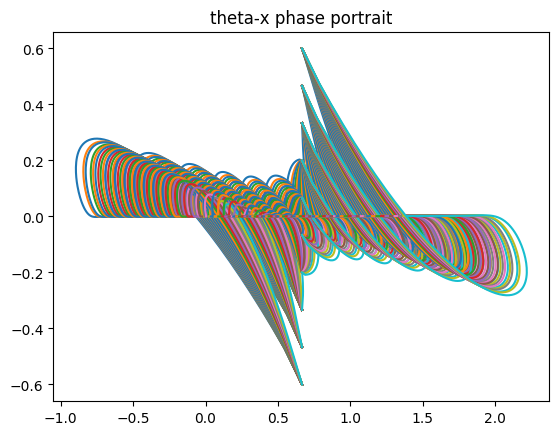

In [94]:
from theorem_tools import plot_eigenvalues
plot_eigenvalues(ae, fdyn, lqr, roa=[1.0, 0.5, 0.6, 0.5], roa_per_axis=[10, 10, 10, 10], n_chunks=6, T_roa=250)